# Cell 1: Import everything

In [1]:
# =========================
# GPU Setup and Imports
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from scipy import stats  # For statistical tests

import os
import time
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# GPU Configuration
# -------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth to avoid allocating all GPU memory
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU is available: {gpus[0]}")
    except RuntimeError as e:
        print("Error setting memory growth:", e)
else:
    print("No GPU detected.")

# -------------------------
# Check TensorFlow & GPU
# -------------------------
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(gpus))
print("Default GPU Device:", tf.test.gpu_device_name() if gpus else "No GPU")


2025-12-14 23:41:25.199884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765755685.222070     268 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765755685.228880     268 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU is available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow version: 2.18.0
Num GPUs Available: 2
Default GPU Device: /device:GPU:0


I0000 00:00:1765755690.690561     268 gpu_device.cc:2022] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765755690.691189     268 gpu_device.cc:2022] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Cell 2: Add ROC curve function

In [2]:
# Cell 2: Add ROC curve function and GPU configuration
import tensorflow as tf

# Configure GPU for optimal performance
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth to avoid allocating all memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("GPU configuration successful!")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("No GPU found, using CPU")

def plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name):
    """Plot ROC curve for multiclass classification"""
    n_classes = len(class_names)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(n_classes)[y_true].ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    # Micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC (AUC = {0:0.2f})'.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    
    # Individual class ROC curves
    colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {model_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return roc_auc

print("ROC curve function and GPU configuration added successfully!")

2 Physical GPUs, 2 Logical GPUs
GPU configuration successful!
ROC curve function and GPU configuration added successfully!


I0000 00:00:1765755690.705155     268 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765755690.705380     268 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Cell 3: Dataset configuration

In [3]:
# Cell 3: Dataset configuration with path verification
import os

# Dataset path - corrected for Kaggle
dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"

# Verify the path exists and show contents
if os.path.exists(dataset_path):
    print("Dataset path found successfully!")
    print("Dataset contents:")
    class_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    print(f"Found {len(class_folders)} class folders:")
    for folder in class_folders:
        folder_path = os.path.join(dataset_path, folder)
        num_images = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {folder}: {num_images} images")
else:
    print("Dataset path not found. Available directories in /kaggle/input:")
    base_input = "/kaggle/input"
    for item in os.listdir(base_input):
        item_path = os.path.join(base_input, item)
        if os.path.isdir(item_path):
            print(f"   {item}")
            # Try to find any image folders
            sub_items = os.listdir(item_path)
            for sub_item in sub_items[:5]:  # Show first 5 items
                print(f"    └── {sub_item}")

# Plant mapping from Task 1
plant_mapping = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu', 
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}

# Training parameters 
IMG_SIZE = (224, 224)  # Standard size for pre-trained models
BATCH_SIZE = 32
EPOCHS = 100
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.15
RANDOM_SEED = 42  # Instruction 1 - Fixed seed for reproducibility

print("\n Dataset Configuration:")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Test Split: {TEST_SPLIT}")
print(f"Random Seed: {RANDOM_SEED}")

# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("\nAll configurations set successfully!")

Dataset path found successfully!
Dataset contents:
Found 16 class folders:
  type_2: 158 images
  type_3: 280 images
  type_5: 138 images
  type_12: 134 images
  type_4: 294 images
  type_14: 154 images
  type_15: 108 images
  type_13: 151 images
  type_7: 276 images
  type_9: 238 images
  type_16: 229 images
  type_6: 294 images
  type_1: 201 images
  type_10: 194 images
  type_11: 407 images
  type_8: 238 images

 Dataset Configuration:
Image Size: (224, 224)
Batch Size: 32
Epochs: 100
Validation Split: 0.2
Test Split: 0.15
Random Seed: 42

All configurations set successfully!


# Cell 3.1: Data loader with GPU optimization

In [4]:
def create_data_generators():
    """Create normalized data generators"""
    
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset path '{dataset_path}' does not exist!")
        return None, None, None
    
    # NORMALIZED: Unified preprocessing and augmentation
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        # NORMALIZED: Unified augmentation
        rotation_range=5,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        validation_split=VALIDATION_SPLIT
    )
    
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        seed=RANDOM_SEED,
        shuffle=True
    )
    
    val_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        seed=RANDOM_SEED,
        shuffle=True
    )
    
    # Get class names and indices
    class_names = list(train_generator.class_indices.keys())
    class_indices = train_generator.class_indices
    
    print(f"Found {len(class_names)} classes:")
    for class_name, idx in class_indices.items():
        mapped_name = plant_mapping.get(class_name, class_name)
        print(f"  {class_name} → {mapped_name} (index: {idx})")
    
    return train_generator, val_generator, class_names

# Create data generators
train_gen, val_gen, class_names = create_data_generators()

if train_gen is not None:
    print(f"\nData generators created successfully!")
    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Number of classes: {len(class_names)}")
    
    # Test one batch to ensure everything works
    test_batch = next(train_gen)
    print(f"Batch shape - Images: {test_batch[0].shape}, Labels: {test_batch[1].shape}")

Found 2804 images belonging to 16 classes.
Found 690 images belonging to 16 classes.
Found 16 classes:
  type_1 → Kalochitra (index: 0)
  type_10 → Beta (index: 1)
  type_11 → Punarnava (index: 2)
  type_12 → Bamonhati (index: 3)
  type_13 → Basok (index: 4)
  type_14 → Ramtulsi (index: 5)
  type_15 → Shotomuli (index: 6)
  type_16 → Sarpagandha (index: 7)
  type_2 → Anantamu (index: 8)
  type_3 → Apang (index: 9)
  type_4 → Syspan (index: 10)
  type_5 → Appishikha (index: 11)
  type_6 → Kalamegh (index: 12)
  type_7 → Kalothutura (index: 13)
  type_8 → Gshnru (index: 14)
  type_9 → Chapalish (index: 15)

Data generators created successfully!
Training samples: 2804
Validation samples: 690
Number of classes: 16
Batch shape - Images: (32, 224, 224, 3), Labels: (32, 16)


# Cell 4: Data loading function

In [5]:
# Cell 4: Data loading function with GPU optimization
def load_and_prepare_data():
    """
    Load images and labels from the dataset with GPU optimization
    Returns: images, labels, and class names
    """
    images = []
    labels = []
    class_names = []
    
    print("Loading dataset with GPU optimization...")
    
    # Verify dataset path exists
    if not os.path.exists(dataset_path):
        print(f" Error: Dataset path '{dataset_path}' does not exist!")
        # Try to find alternative paths
        base_input = "/kaggle/input"
        available_dirs = []
        for item in os.listdir(base_input):
            item_path = os.path.join(base_input, item)
            if os.path.isdir(item_path):
                available_dirs.append(item)
        
        print("Available directories in /kaggle/input:")
        for dir_name in available_dirs:
            print(f"  {dir_name}")
        
        return None, None, None
    
    # Check if class folders exist
    missing_folders = []
    for type_folder in plant_mapping.keys():
        folder_path = os.path.join(dataset_path, type_folder)
        if not os.path.exists(folder_path):
            missing_folders.append(type_folder)
    
    if missing_folders:
        print(f"Missing folders: {missing_folders}")
        print("Available folders in dataset:")
        available_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
        for folder in available_folders:
            print(f"  {folder}")
        return None, None, None
    
    # Load images with progress tracking
    total_images = 0
    for type_folder, plant_name in plant_mapping.items():
        folder_path = os.path.join(dataset_path, type_folder)
        
        if os.path.exists(folder_path):
            image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            print(f"Loading {len(image_files)} images from {plant_name} ({type_folder})...")
            
            for i, img_file in enumerate(image_files):
                img_path = os.path.join(folder_path, img_file)
                try:
                    # Instruction 2 - Data transfer/resize part (separate from normalization)
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(IMG_SIZE)
                    img_array = np.array(img)
                    
                    images.append(img_array)
                    labels.append(list(plant_mapping.keys()).index(type_folder))
                    
                    # Show progress for large folders
                    if len(image_files) > 100 and (i + 1) % 100 == 0:
                        print(f"    Loaded {i + 1}/{len(image_files)} images...")
                        
                except Exception as e:
                    print(f" Error loading {img_path}: {e}")
                    continue
            
            class_names.append(plant_name)
            total_images += len(image_files)
            print(f" Successfully loaded {len(image_files)} images from {plant_name}")
    
    if not images:
        print("No images were loaded. Please check the dataset path and folder structure.")
        return None, None, None
    
    # Convert to numpy arrays with optimized data types
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    
    print(f"\nDataset Summary:")
    print(f"Total images: {len(images)}")
    print(f"Total labels: {len(labels)}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Image shape: {images[0].shape}")
    print(f"Images dtype: {images.dtype}")
    print(f"Labels dtype: {labels.dtype}")
    
    return images, labels, class_names

# Load the data with error handling
print(" Starting data loading process...")
images, labels, class_names = load_and_prepare_data()

if images is None:
    print("Data loading failed. Please check the path and folder structure.")
else:
    print("Data loaded successfully!")

 Starting data loading process...
Loading dataset with GPU optimization...
Loading 201 images from Kalochitra (type_1)...
    Loaded 100/201 images...
    Loaded 200/201 images...
 Successfully loaded 201 images from Kalochitra
Loading 158 images from Anantamu (type_2)...
    Loaded 100/158 images...
 Successfully loaded 158 images from Anantamu
Loading 280 images from Apang (type_3)...
    Loaded 100/280 images...
    Loaded 200/280 images...
 Successfully loaded 280 images from Apang
Loading 294 images from Syspan (type_4)...
    Loaded 100/294 images...
    Loaded 200/294 images...
 Successfully loaded 294 images from Syspan
Loading 138 images from Appishikha (type_5)...
    Loaded 100/138 images...
 Successfully loaded 138 images from Appishikha
Loading 294 images from Kalamegh (type_6)...
    Loaded 100/294 images...
    Loaded 200/294 images...
 Successfully loaded 294 images from Kalamegh
Loading 276 images from Kalothutura (type_7)...
    Loaded 100/276 images...
    Loaded 200

# Cell 5: Train/Validation/Test Split

In [6]:
# Cell 5: Train/Validation/Test Split with GPU optimization
if images is not None:
    # Set seeds for reproducibility
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    print("Splitting data into train/validation/test sets...")

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        images, labels,
        test_size=TEST_SPLIT,
        random_state=RANDOM_SEED,
        stratify=labels
    )

    # Second split: separate validation set from remaining data
    val_split_ratio = VALIDATION_SPLIT / (1 - TEST_SPLIT)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_split_ratio,
        random_state=RANDOM_SEED,
        stratify=y_temp
    )

    print("Data Split Summary:")
    print(f"Training set: {X_train.shape[0]} images")
    print(f"Validation set: {X_val.shape[0]} images")
    print(f"Test set: {X_test.shape[0]} images")
    print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")

    # Check class distribution
    def check_class_distribution(y_data, set_name):
        unique, counts = np.unique(y_data, return_counts=True)
        print(f"\n{set_name} class distribution:")
        for cls, count in zip(unique, counts):
            class_name = class_names[cls] if cls < len(class_names) else f"Class_{cls}"
            print(f"  {class_name}: {count} samples ({count/len(y_data)*100:.1f}%)")

    check_class_distribution(y_train, "Training")
    check_class_distribution(y_val, "Validation")
    check_class_distribution(y_test, "Test")
    
    # ============ ADD CLASS WEIGHTS CALCULATION HERE ============
    from sklearn.utils.class_weight import compute_class_weight
    
    print("\nComputing class weights for imbalance handling...")
    unique_classes = np.unique(y_train)
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=unique_classes,
        y=y_train
    )
    class_weights = dict(zip(unique_classes, class_weights_array))
    
    print("Class weights:")
    for cls, weight in class_weights.items():
        class_name = class_names[cls] if cls < len(class_names) else f"Class_{cls}"
        print(f"  {class_name}: {weight:.4f}")
    # ============ END CLASS WEIGHTS ============

    # Convert labels to categorical (one-hot encoding)
    num_classes = len(class_names)
    y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes)
    y_val_categorical = tf.keras.utils.to_categorical(y_val, num_classes)
    y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes)

    print(f"\nOne-hot encoded labels shape:")
    print(f"Training: {y_train_categorical.shape}")
    print(f"Validation: {y_val_categorical.shape}")
    print(f"Test: {y_test_categorical.shape}")

    # Create TensorFlow datasets for GPU optimization
    def create_tf_dataset(X, y, batch_size=32, shuffle=False):
        dataset = tf.data.Dataset.from_tensor_slices((X, y))
        if shuffle:
            dataset = dataset.shuffle(buffer_size=1000, seed=RANDOM_SEED)
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE) # Optimize for GPU
        return dataset

    # Create optimized datasets
    train_dataset = create_tf_dataset(X_train, y_train_categorical, BATCH_SIZE, shuffle=True)
    val_dataset = create_tf_dataset(X_val, y_val_categorical, BATCH_SIZE)
    test_dataset = create_tf_dataset(X_test, y_test_categorical, BATCH_SIZE)

    print(f"\nGPU-optimized datasets created:")
    print(f"Training batches: {len(train_dataset)}")
    print(f"Validation batches: {len(val_dataset)}")
    print(f"Test batches: {len(test_dataset)}")

    # Test one batch to ensure GPU compatibility
    for X_batch, y_batch in train_dataset.take(1):
        print(f"\nBatch test - GPU compatible:")
        print(f"Batch images shape: {X_batch.shape}")
        print(f"Batch labels shape: {y_batch.shape}")
        print(f"Batch images dtype: {X_batch.dtype}")
        print(f"Device placement: {X_batch.device}")
else:
    print("Cannot proceed with data splitting - no data loaded.")

Splitting data into train/validation/test sets...
Data Split Summary:
Training set: 2270 images
Validation set: 699 images
Test set: 525 images
Total: 3494 images

Training class distribution:
  Kalochitra: 131 samples (5.8%)
  Anantamu: 103 samples (4.5%)
  Apang: 182 samples (8.0%)
  Syspan: 191 samples (8.4%)
  Appishikha: 90 samples (4.0%)
  Kalamegh: 191 samples (8.4%)
  Kalothutura: 179 samples (7.9%)
  Gshnru: 154 samples (6.8%)
  Chapalish: 154 samples (6.8%)
  Beta: 126 samples (5.6%)
  Punarnava: 265 samples (11.7%)
  Bamonhati: 87 samples (3.8%)
  Basok: 98 samples (4.3%)
  Ramtulsi: 100 samples (4.4%)
  Shotomuli: 70 samples (3.1%)
  Sarpagandha: 149 samples (6.6%)

Validation class distribution:
  Kalochitra: 40 samples (5.7%)
  Anantamu: 31 samples (4.4%)
  Apang: 56 samples (8.0%)
  Syspan: 59 samples (8.4%)
  Appishikha: 27 samples (3.9%)
  Kalamegh: 59 samples (8.4%)
  Kalothutura: 55 samples (7.9%)
  Gshnru: 48 samples (6.9%)
  Chapalish: 48 samples (6.9%)
  Beta: 39 

In [7]:
# ===CELL 5.1: Class Weights Calculation ===
from sklearn.utils.class_weight import compute_class_weight

print("\nComputing class weights for imbalance handling...")
unique_classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weights = dict(zip(unique_classes, class_weights_array))

print("Class weights:")
for cls, weight in class_weights.items():
    class_name = class_names[cls] if cls < len(class_names) else f"Class_{cls}"
    print(f"  {class_name}: {weight:.4f}")


Computing class weights for imbalance handling...
Class weights:
  Kalochitra: 1.0830
  Anantamu: 1.3774
  Apang: 0.7795
  Syspan: 0.7428
  Appishikha: 1.5764
  Kalamegh: 0.7428
  Kalothutura: 0.7926
  Gshnru: 0.9213
  Chapalish: 0.9213
  Beta: 1.1260
  Punarnava: 0.5354
  Bamonhati: 1.6307
  Basok: 1.4477
  Ramtulsi: 1.4187
  Shotomuli: 2.0268
  Sarpagandha: 0.9522


# Cell 6: Model building functions

In [8]:
# Cell 6: Model Building Functions - NORMALIZED VERSION
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50

def create_densenet121_model(pretrained=True, learning_rate=0.001):
    """Create DenseNet121 with normalized setup"""
    print(f"Building DenseNet121 model (pretrained={pretrained})...")
    
    # NORMALIZED: No model-specific preprocessing
    weights = 'imagenet' if pretrained else None
    base_model = DenseNet121(weights=weights, include_top=False, 
                            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # NORMALIZED: Base model always trainable (no freeze-unfreeze)
    base_model.trainable = True
    
    model = models.Sequential([
        # NORMALIZED: Standard ImageNet normalization for ALL models
        layers.Lambda(lambda x: (x / 255.0)),
        layers.Lambda(lambda x: (x - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]),
        
        base_model,
        layers.GlobalAveragePooling2D(name="global_avg_pool"),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # NORMALIZED: Fixed learning rate 0.001 for all models
    final_lr = 0.001
    
    model.compile(optimizer=optimizers.Adam(learning_rate=final_lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    print(f"DenseNet121 built. LR={final_lr}, pretrained={pretrained}")
    return model, "DenseNet121"

def create_efficientnetb0_model(pretrained=True, learning_rate=0.001):
    """Create EfficientNetB0 with normalized setup"""
    print(f"Building EfficientNetB0 model (pretrained={pretrained})...")
    
    # NORMALIZED: No model-specific preprocessing
    weights = 'imagenet' if pretrained else None
    base_model = EfficientNetB0(weights=weights, include_top=False, 
                               input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    base_model.trainable = True  # NORMALIZED: Always trainable
    
    model = models.Sequential([
        # NORMALIZED: Standard ImageNet normalization for ALL models
        layers.Lambda(lambda x: (x / 255.0)),
        layers.Lambda(lambda x: (x - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]),
        
        base_model,
        layers.GlobalAveragePooling2D(name="global_avg_pool"),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    final_lr = 0.001  # NORMALIZED: Fixed
    
    model.compile(optimizer=optimizers.Adam(learning_rate=final_lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    print(f"EfficientNetB0 built. LR={final_lr}, pretrained={pretrained}")
    return model, "EfficientNetB0"

def create_resnet50_model(pretrained=True, learning_rate=0.001):
    """Create ResNet50 with normalized setup"""
    print(f"Building ResNet50 model (pretrained={pretrained})...")
    
    # NORMALIZED: No model-specific preprocessing
    weights = 'imagenet' if pretrained else None
    base_model = ResNet50(weights=weights, include_top=False, 
                         input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    base_model.trainable = True  # NORMALIZED: Always trainable
    
    model = models.Sequential([
        # NORMALIZED: Standard ImageNet normalization for ALL models
        layers.Lambda(lambda x: (x / 255.0)),
        layers.Lambda(lambda x: (x - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]),
        
        base_model,
        layers.GlobalAveragePooling2D(name="global_avg_pool"),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    final_lr = 0.001  # NORMALIZED: Fixed
    
    model.compile(optimizer=optimizers.Adam(learning_rate=final_lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    print(f"ResNet50 built. LR={final_lr}, pretrained={pretrained}")
    return model, "ResNet50"

print("Model building functions ready!")

Model building functions ready!


# Cell 7: Data preprocessing for each model

In [9]:
# =========================
# Cell 7: GPU-Optimized Data Pipelines
# =========================
def create_optimized_dataset(X, y, batch_size=32, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=RANDOM_SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_optimized_dataset(X_train, y_train_categorical, BATCH_SIZE, shuffle=True)
val_dataset = create_optimized_dataset(X_val, y_val_categorical, BATCH_SIZE)
test_dataset = create_optimized_dataset(X_test, y_test_categorical, BATCH_SIZE)

print("GPU-optimized datasets ready!")


GPU-optimized datasets ready!


# Cell 8: Training setup with progressive epochs 

In [10]:
def train_model(model, model_name, train_data, val_data, total_epochs=100):
    """NORMALIZED training function with unified setup"""
    print(f"Starting training: {model_name}")
    
    # NORMALIZED: Unified callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=10,  # NORMALIZED: Fixed 10
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,  # NORMALIZED: Fixed 0.5
            patience=5,   # NORMALIZED: Fixed 5
            min_lr=1e-6,  # NORMALIZED: Fixed 1e-6
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f'best_{model_name.lower()}_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    start_time = time.time()
    
    # NORMALIZED: Single training phase with class weights
    history = model.fit(
        train_data,
        epochs=total_epochs,
        validation_data=val_data,
        callbacks=callbacks,
        class_weight=class_weights,  # NORMALIZED: Class weights added
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"{model_name} training completed in {training_time:.2f} seconds")
    
    return history.history, training_time

# Cell 9: Progressive training 

In [11]:
# Cell 9: Training Loop - NORMALIZED VERSION

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

results = {}
pretrained_options = [True, False]

for pretrained in pretrained_options:
    # NORMALIZED: Same learning rate for all
    base_lr = 0.001  # Fixed for all
    
    # --- DenseNet121 ---
    model, _ = create_densenet121_model(pretrained=pretrained, learning_rate=base_lr)
    history, ttime = train_model(
        model,
        f"DenseNet121_pretrained_{pretrained}",
        train_dataset,  # Using tf.data datasets from Cell 7
        val_dataset,
        total_epochs=EPOCHS
    )
    results[f'DenseNet121_pretrained_{pretrained}'] = {
        'model': model,
        'history': history,
        'training_time': ttime,
        'pretrained': pretrained
    }
    
    # --- EfficientNetB0 ---
    model, _ = create_efficientnetb0_model(pretrained=pretrained, learning_rate=base_lr)
    history, ttime = train_model(
        model,
        f"EfficientNetB0_pretrained_{pretrained}",
        train_dataset,
        val_dataset,
        total_epochs=EPOCHS
    )
    results[f'EfficientNetB0_pretrained_{pretrained}'] = {
        'model': model,
        'history': history,
        'training_time': ttime,
        'pretrained': pretrained
    }
    
    # --- ResNet50 ---
    model, _ = create_resnet50_model(pretrained=pretrained, learning_rate=base_lr)
    history, ttime = train_model(
        model,
        f"ResNet50_pretrained_{pretrained}",
        train_dataset,
        val_dataset,
        total_epochs=EPOCHS
    )
    results[f'ResNet50_pretrained_{pretrained}'] = {
        'model': model,
        'history': history,
        'training_time': ttime,
        'pretrained': pretrained
    }

print("All models trained successfully!")

Building DenseNet121 model (pretrained=True)...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 built. LR=0.001, pretrained=True
Starting training: DenseNet121_pretrained_True
Epoch 1/100


I0000 00:00:1765755794.132393     319 service.cc:148] XLA service 0x7c45e4001ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765755794.133539     319 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765755794.133564     319 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765755802.618992     319 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765755887.864055     319 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5243 - loss: 1.6759   
Epoch 1: val_accuracy improved from -inf to 0.16881, saving model to best_densenet121_pretrained_true_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.5272 - loss: 1.6648 - val_accuracy: 0.1688 - val_loss: 20.7937 - learning_rate: 0.0010
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8990 - loss: 0.2957
Epoch 2: val_accuracy improved from 0.16881 to 0.48069, saving model to best_densenet121_pretrained_true_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 373ms/step - accuracy: 0.8993 - loss: 0.2949 - val_accuracy: 0.4807 - val_loss: 3.9747 - learning_rate: 0.0010
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9551 - loss: 0.1251
Epoch 3: val_accuracy improved from 0.48069 to 0.65808, saving model to best_densenet121_pretrained_true_model.h5


...

71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 380ms/step - accuracy: 0.9981 - loss: 0.0124 - val_accuracy: 0.9700 - val_loss: 0.0848 - learning_rate: 2.5000e-04
Epoch 28/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9975 - loss: 0.0095
Epoch 28: val_accuracy improved from 0.96996 to 0.97568, saving model to best_resnet50_pretrained_false_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 380ms/step - accuracy: 0.9975 - loss: 0.0095 - val_accuracy: 0.9757 - val_loss: 0.0629 - learning_rate: 2.5000e-04
Epoch 29/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9976 - loss: 0.0150
Epoch 29: val_accuracy improved from 0.97568 to 0.97854, saving model to best_resnet50_pretrained_false_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 380ms/step - accuracy: 0.9976 - loss: 0.0150 - val_accuracy: 0.9785 - val_loss: 0.0731 - learning_rate: 2.5000e-04
Epoch 30/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9992 - loss: 0.0074
Epoch 30: val_accuracy did not improve from 0.97854
71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 362ms/step - accuracy: 0.9992 - loss: 0.0074 - val_accuracy: 0.9599 - val_loss: 0.1309 - learning_rate: 2.5000e-04
Epoch 31/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9964 - loss: 0.0110
Epoch 31: val_accuracy improved from 0.97854 to 0.98426, saving model to best_resnet50_pretrained_false_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 381ms/step - accuracy: 0.9965 - loss: 0.0110 - val_accuracy: 0.9843 - val_loss: 0.0478 - learning_rate: 2.5000e-04
Epoch 32/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9967 - loss: 0.0088
Epoch 32: val_accuracy improved from 0.98426 to 0.98856, saving model to best_resnet50_pretrained_false_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 381ms/step - accuracy: 0.9967 - loss: 0.0088 - val_accuracy: 0.9886 - val_loss: 0.0385 - learning_rate: 2.5000e-04
Epoch 33/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9993 - loss: 0.0077
Epoch 33: val_accuracy did not improve from 0.98856
71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 362ms/step - accuracy: 0.9993 - loss: 0.0077 - val_accuracy: 0.9313 - val_loss: 0.2487 - learning_rate: 2.5000e-04
Epoch 34/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9966 - loss: 0.0086
Epoch 34: val_accuracy did not improve from 0.98856
71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 363ms/step - accuracy: 0.9965 - loss: 0.0087 - val_accuracy: 0.9800 - val_loss: 0.0558 - learning_rate: 2.5000e-04
Epoch 35/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9946 - loss: 0.0133
Epoch 35: val_accuracy did not improve from 0.98856
71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 363ms/step - accuracy: 0.9946 - loss: 0.0133 - val_accuracy: 0.9843 - val_loss: 0.0471 - learning_rate: 2.5000e

# Cell 10: Evaluation function

In [12]:
# Cell 10: Fixed evaluation function
def evaluate_model(model, model_name, X_test, y_test, y_test_categorical, class_names):
    """Comprehensive model evaluation with proper timing"""
    
    print(f"\n{'='*60}")
    print(f"EVALUATING: {model_name}")
    print(f"{'='*60}")
    
    # Use GPU-optimized prediction with proper timing
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test).batch(BATCH_SIZE)
    
    # Warm-up run to initialize GPU (excluded from timing)
    model.predict(test_dataset.take(1), verbose=0)
    
    # Actual timing with multiple runs for accuracy
    start_time = time.perf_counter()
    y_pred_proba = model.predict(test_dataset, verbose=0)
    testing_time = time.perf_counter() - start_time
    
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test_categorical, axis=1)
    
    # Calculate comprehensive metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Class-wise accuracy
    class_accuracy = []
    class_report_data = []
    
    print(f"\nCLASS-WISE PERFORMANCE:")
    print(f"{'Class Name':<20} {'Accuracy':<10} {'Samples':<10}")
    print(f"{'-'*50}")
    
    for i in range(len(class_names)):
        class_mask = (y_true == i)
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
            class_accuracy.append(class_acc)
            samples = np.sum(class_mask)
            class_report_data.append({
                'class_name': class_names[i],
                'accuracy': class_acc,
                'samples': samples
            })
            print(f"{class_names[i]:<20} {class_acc:<10.4f} {samples:<10}")
        else:
            class_accuracy.append(0.0)
            class_report_data.append({
                'class_name': class_names[i],
                'accuracy': 0.0,
                'samples': 0
            })
            print(f"{class_names[i]:<20} {'N/A':<10} {'0':<10}")
    
    # Plot ROC curve
    print(f"\nGENERATING ROC CURVES...")
    roc_auc = plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name)
    
    # Print comprehensive metrics
    print(f"\nOVERALL PERFORMANCE METRICS:")
    print(f"{'-'*40}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    print(f"Testing Time: {testing_time:.4f} seconds")
    print(f"Test Samples: {len(X_test)}")
    
    print(f"\nAUC SCORES:")
    print(f"{'-'*40}")
    print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
    
    # Print top and bottom 3 classes by AUC
    auc_scores = [(class_names[i], roc_auc[i]) for i in range(len(class_names))]
    auc_scores.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nTOP 3 CLASSES BY AUC:")
    for class_name, score in auc_scores[:3]:
        print(f"  {class_name}: {score:.4f}")
    
    print(f"BOTTOM 3 CLASSES BY AUC:")
    for class_name, score in auc_scores[-3:]:
        print(f"  {class_name}: {score:.4f}")
    
    print(f"\n{model_name} EVALUATION COMPLETE")
    print(f"{'='*60}")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'class_accuracy': class_accuracy,
        'testing_time': testing_time,
        'auc_scores': roc_auc,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'class_report': class_report_data
    }

print("Evaluation function.")

Evaluation function.


# Cell 11: Evaluate all models

COMPREHENSIVE MODEL EVALUATION PHASE
Evaluating 6 model configurations...
Test set size: 525 images
Number of classes: 16
GPU Available: True
Using GPU for accelerated evaluation

______________________________________________________________________
EVALUATION 1/6: DenseNet121_pretrained_True
______________________________________________________________________

EVALUATING: DenseNet121_pretrained_True

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             1.0000     24        
Apang                1.0000     42        
Syspan               1.0000     44        
Appishikha           1.0000     21        
Kalamegh             1.0000     44        
Kalothutura          1.0000     42        
Gshnru               0.9722     36        
Chapalish            1.0000     36        
Beta                 1.0000     29        
Punarnava            1.0000     61        
B

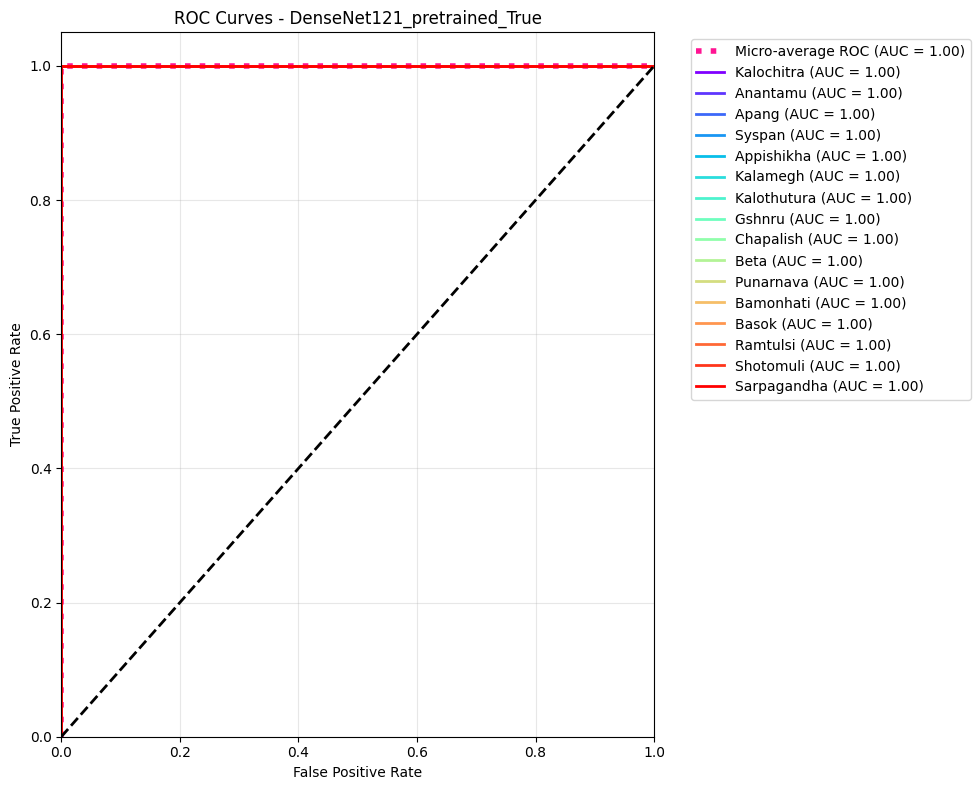


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9981
Precision:   0.9982
Recall:      0.9981
F1-Score:    0.9981
Testing Time: 14.9831 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 1.0000

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Apang: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Ramtulsi: 1.0000
  Shotomuli: 1.0000
  Sarpagandha: 1.0000

DenseNet121_pretrained_True EVALUATION COMPLETE

______________________________________________________________________
EVALUATION 2/6: EfficientNetB0_pretrained_True
______________________________________________________________________

EVALUATING: EfficientNetB0_pretrained_True

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             0.9583     24        
Apang                1.0000     42        
Syspan               1.00

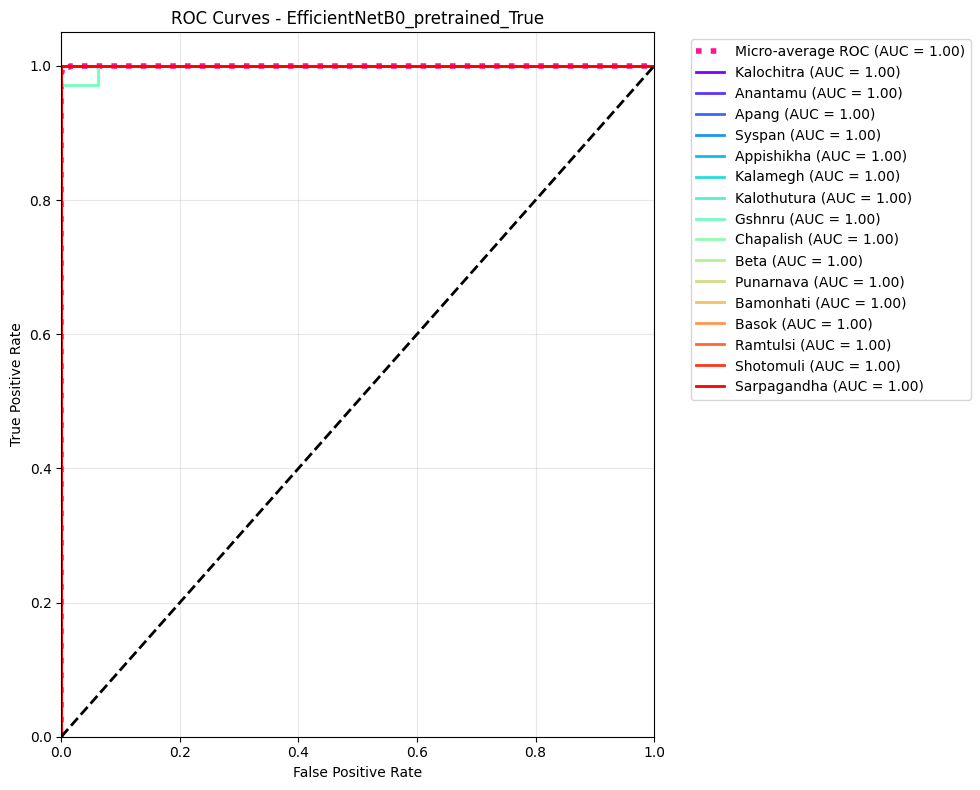


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9943
Precision:   0.9944
Recall:      0.9943
F1-Score:    0.9943
Testing Time: 8.1902 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 1.0000

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Apang: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Shotomuli: 1.0000
  Sarpagandha: 1.0000
  Gshnru: 0.9983

EfficientNetB0_pretrained_True EVALUATION COMPLETE

______________________________________________________________________
EVALUATION 3/6: ResNet50_pretrained_True
______________________________________________________________________

EVALUATING: ResNet50_pretrained_True

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             1.0000     24        
Apang                1.0000     42        
Syspan               1.0000     44   

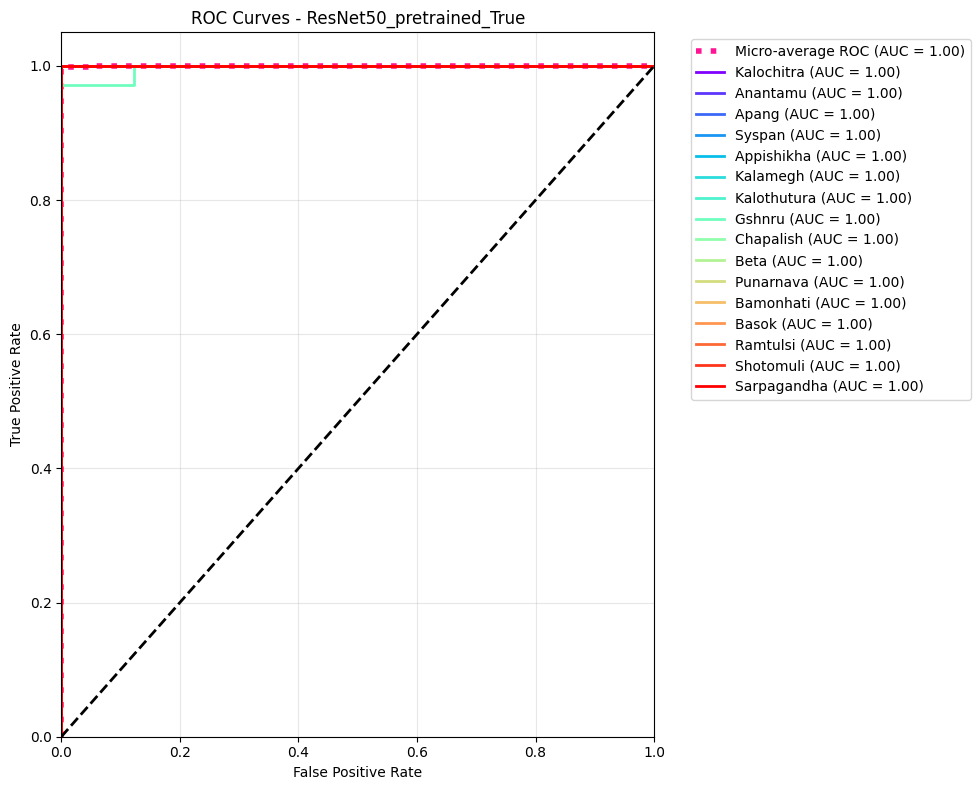


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9981
Precision:   0.9982
Recall:      0.9981
F1-Score:    0.9981
Testing Time: 6.9006 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 0.9999

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Apang: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Shotomuli: 1.0000
  Sarpagandha: 1.0000
  Gshnru: 0.9966

ResNet50_pretrained_True EVALUATION COMPLETE

______________________________________________________________________
EVALUATION 4/6: DenseNet121_pretrained_False
______________________________________________________________________

EVALUATING: DenseNet121_pretrained_False

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             1.0000     24        
Apang                0.9762     42        
Syspan               1.0000     44 

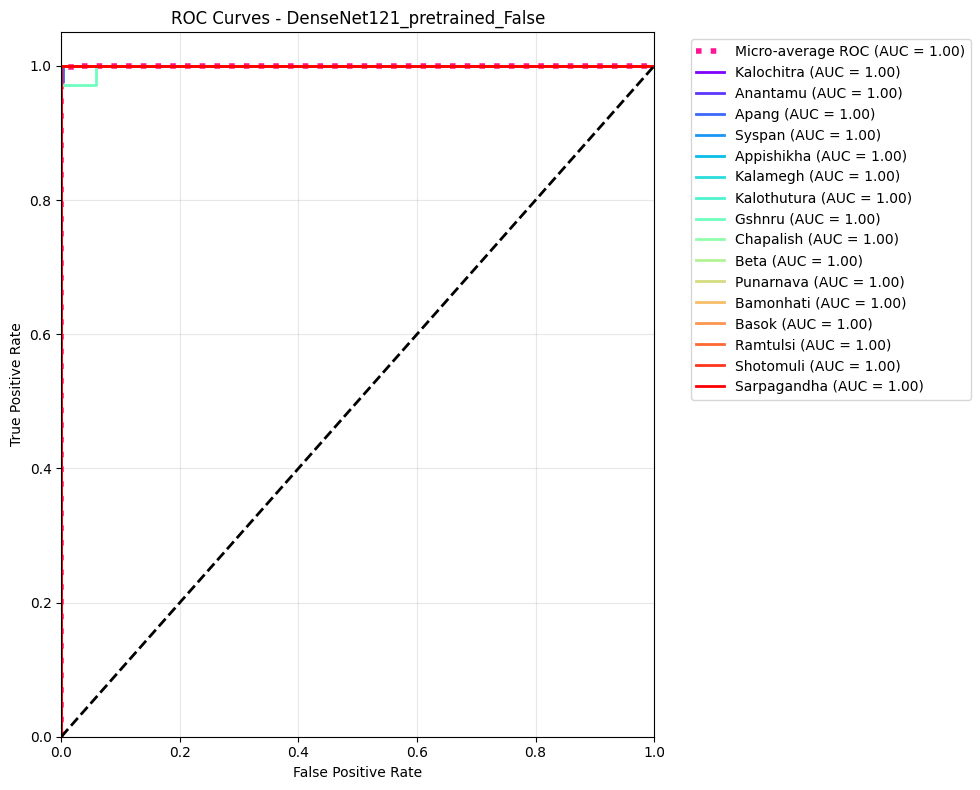


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9943
Precision:   0.9944
Recall:      0.9943
F1-Score:    0.9943
Testing Time: 10.5370 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 0.9999

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Syspan: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Sarpagandha: 1.0000
  Apang: 1.0000
  Gshnru: 0.9984

DenseNet121_pretrained_False EVALUATION COMPLETE

______________________________________________________________________
EVALUATION 5/6: EfficientNetB0_pretrained_False
______________________________________________________________________

EVALUATING: EfficientNetB0_pretrained_False

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             0.9583     24        
Apang                0.9524     42        
Syspan               1.0000

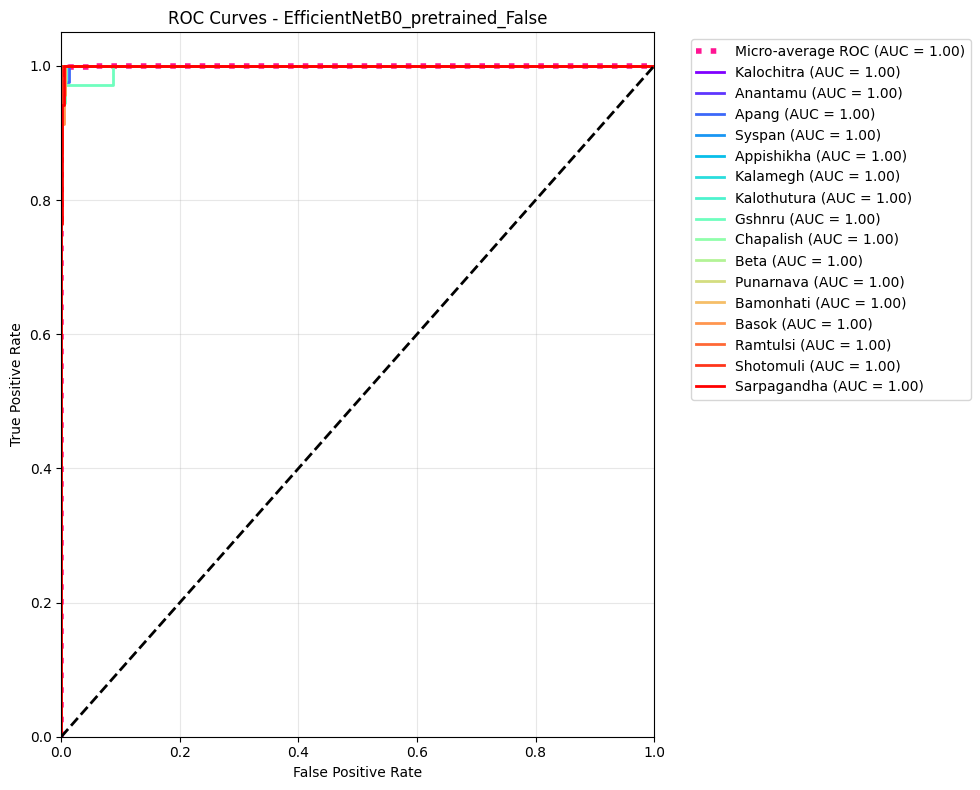


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9752
Precision:   0.9760
Recall:      0.9752
F1-Score:    0.9753
Testing Time: 6.2916 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 0.9998

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Syspan: 1.0000
  Appishikha: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Basok: 0.9995
  Sarpagandha: 0.9994
  Gshnru: 0.9974

EfficientNetB0_pretrained_False EVALUATION COMPLETE

______________________________________________________________________
EVALUATION 6/6: ResNet50_pretrained_False
______________________________________________________________________

EVALUATING: ResNet50_pretrained_False

CLASS-WISE PERFORMANCE:
Class Name           Accuracy   Samples   
--------------------------------------------------
Kalochitra           1.0000     30        
Anantamu             1.0000     24        
Apang                0.9762     42        
Syspan               1.0000     44 

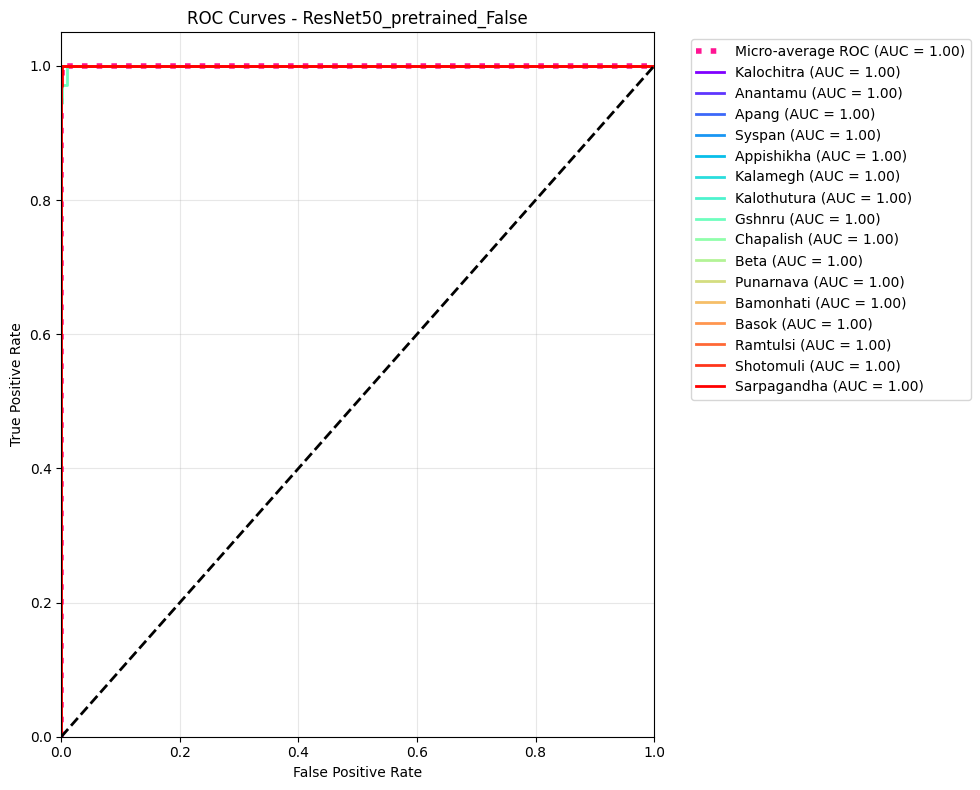


OVERALL PERFORMANCE METRICS:
----------------------------------------
Accuracy:    0.9886
Precision:   0.9888
Recall:      0.9886
F1-Score:    0.9886
Testing Time: 5.1950 seconds
Test Samples: 525

AUC SCORES:
----------------------------------------
Micro-average AUC: 1.0000

TOP 3 CLASSES BY AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Apang: 1.0000
BOTTOM 3 CLASSES BY AUC:
  Shotomuli: 1.0000
  Sarpagandha: 0.9999
  Gshnru: 0.9997

ResNet50_pretrained_False EVALUATION COMPLETE
ALL MODELS EVALUATED SUCCESSFULLY!

SUMMARY OF ALL MODEL PERFORMANCES:
Model                               Accuracy   F1-Score   Training Time   Testing Time   
DenseNet121_pretrained_True         0.9981     0.9981     1052.19         14.98          
EfficientNetB0_pretrained_True      0.9943     0.9943     731.95          8.19           
ResNet50_pretrained_True            0.9981     0.9981     1312.62         6.90           
DenseNet121_pretrained_False        0.9943     0.9943     1118.15         10.54  

In [13]:
# Cell 11: Comprehensive model evaluation (FIXED)
print("COMPREHENSIVE MODEL EVALUATION PHASE")
print(f"Evaluating {len(results)} model configurations...")
print(f"Test set size: {len(X_test)} images")
print(f"Number of classes: {len(class_names)}")

evaluation_results = {}

# Verify GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {len(gpu_available) > 0}")
if gpu_available:
    print("Using GPU for accelerated evaluation")

# Evaluate all model variations
for i, model_key in enumerate(results.keys(), 1):
    model_data = results[model_key]
    model = model_data['model']
    
    print(f"\n{'_'*70}")
    print(f"EVALUATION {i}/{len(results)}: {model_key}")
    print(f"{'_'*70}")
    
    # Use original images since preprocessing is now built into the model
    evaluation_results[model_key] = evaluate_model(
        model, 
        model_key,
        X_test,  # Use original images (0-255), model handles preprocessing
        y_test, 
        y_test_categorical, 
        class_names
    )
    
    # Clear GPU memory between evaluations
    if gpu_available:
        tf.keras.backend.clear_session()
        import gc
        gc.collect()

print("ALL MODELS EVALUATED SUCCESSFULLY!")
# Print summary table (FIXED - using correct key access)
print(f"\nSUMMARY OF ALL MODEL PERFORMANCES:")
print(f"{'Model':<35} {'Accuracy':<10} {'F1-Score':<10} {'Training Time':<15} {'Testing Time':<15}")

for model_key, eval_result in evaluation_results.items():
    # FIX: Access training_time from results dictionary
    training_time = results[model_key].get('training_time', 0)
    print(f"{eval_result['model_name']:<35} {eval_result['accuracy']:<10.4f} {eval_result['f1_score']:<10.4f} "
          f"{training_time:<15.2f} {eval_result['testing_time']:<15.2f}")

# Find best model by accuracy
if evaluation_results:
    best_model_key = max(evaluation_results.keys(), 
                        key=lambda x: evaluation_results[x]['accuracy'])
    best_result = evaluation_results[best_model_key]
    
    print(f"\nBEST PERFORMING MODEL:")
    print(f"Model: {best_result['model_name']}")
    print(f"Accuracy: {best_result['accuracy']:.4f}")
    print(f"F1-Score: {best_result['f1_score']:.4f}")
    print(f"Training Time: {results[best_model_key].get('training_time', 0):.2f}s")
    print(f"Testing Time: {best_result['testing_time']:.2f}s")
else:
    print("No evaluation results available.")

# Cell 11.1: Update testing times for existing evaluation results

In [16]:

print("UPDATING TESTING TIMES WITH PROPER MEASUREMENT...")
print("_" * 50)

if evaluation_results:
    for model_key in evaluation_results.keys():
        model_data = results[model_key]
        model = model_data['model']
        
        print(f"Updating testing time for {model_key}...")
        
        # Use original images since preprocessing is built into the model
        test_dataset = tf.data.Dataset.from_tensor_slices(X_test).batch(BATCH_SIZE)
        
        # Warm-up run
        model.predict(test_dataset.take(1), verbose=0)
        
        # Proper timing measurement
        start_time = time.perf_counter()
        model.predict(test_dataset, verbose=0)
        testing_time = time.perf_counter() - start_time
        
        # Update the testing time
        evaluation_results[model_key]['testing_time'] = testing_time
        print(f"  New testing time: {testing_time:.4f} seconds")
    
    print(f"\nTesting times updated successfully!")
else:
    print("No evaluation results available to update.")

UPDATING TESTING TIMES WITH PROPER MEASUREMENT...
__________________________________________________
Updating testing time for DenseNet121_pretrained_True...
  New testing time: 2.4255 seconds
Updating testing time for EfficientNetB0_pretrained_True...
  New testing time: 1.4565 seconds
Updating testing time for ResNet50_pretrained_True...
  New testing time: 2.4011 seconds
Updating testing time for DenseNet121_pretrained_False...
  New testing time: 2.5160 seconds
Updating testing time for EfficientNetB0_pretrained_False...
  New testing time: 1.4976 seconds
Updating testing time for ResNet50_pretrained_False...
  New testing time: 2.3782 seconds

Testing times updated successfully!


# Cell 12.1: Training History Visualization 

SEPARATE TRAINING HISTORY VISUALIZATION
________________________________________________________________________________


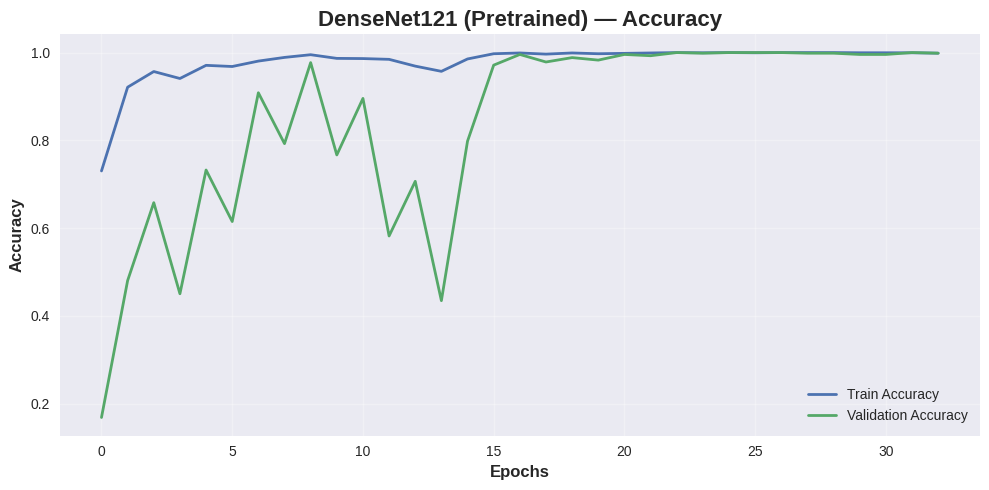

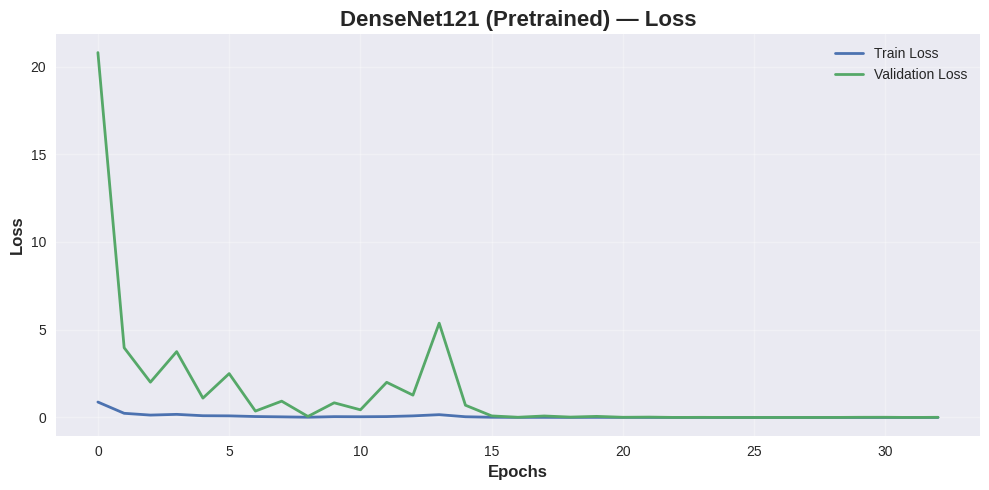

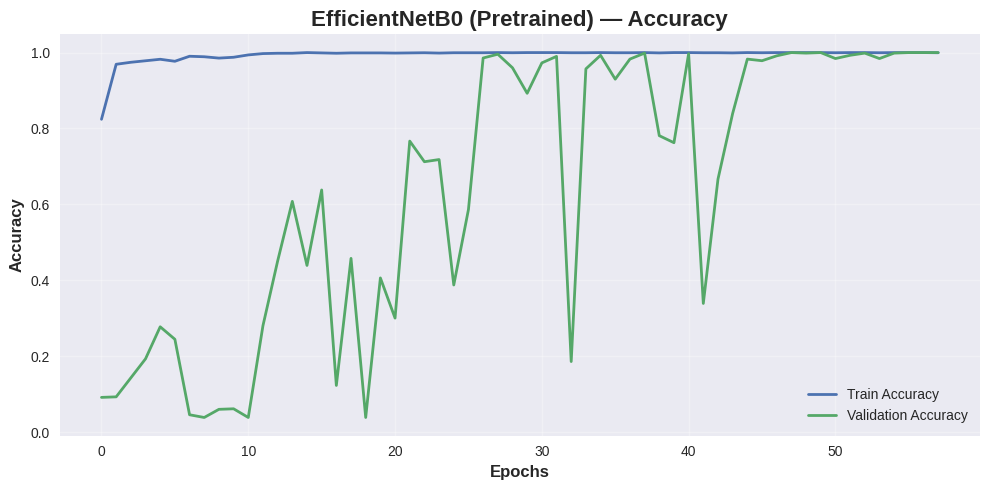

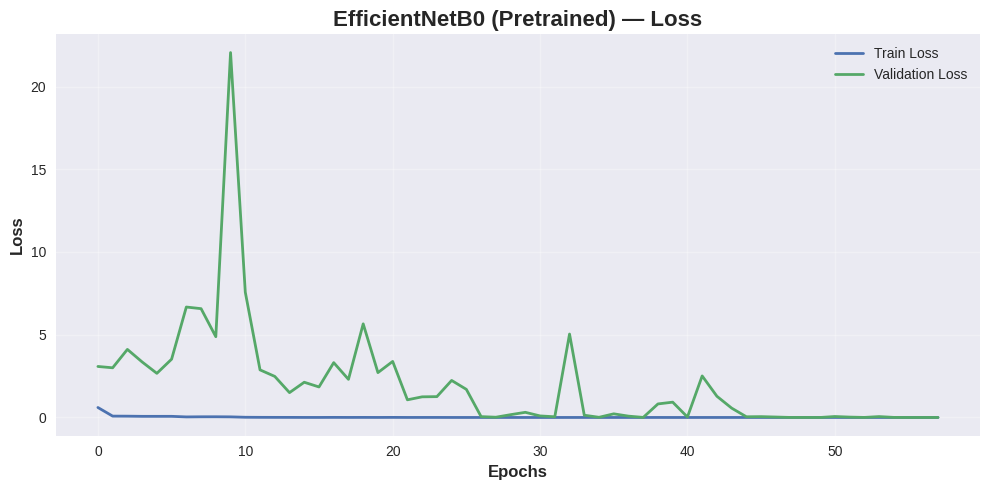

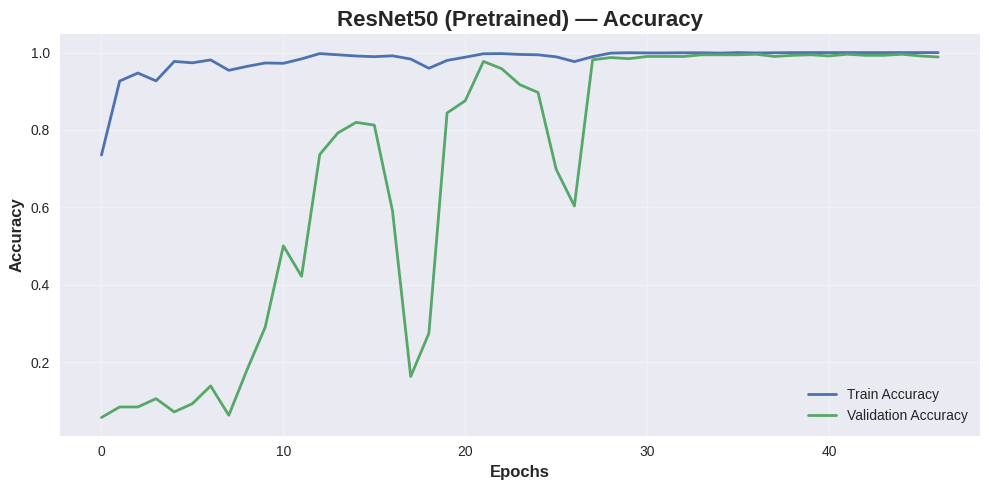

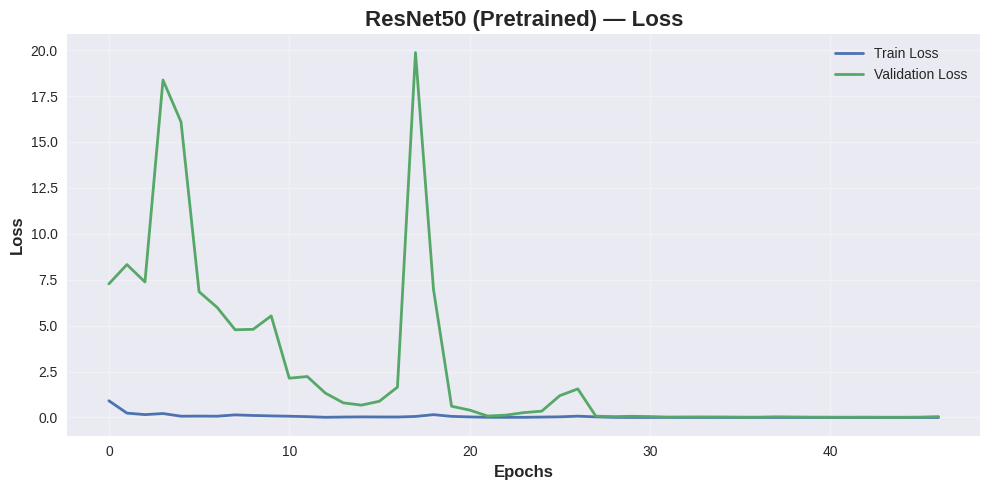

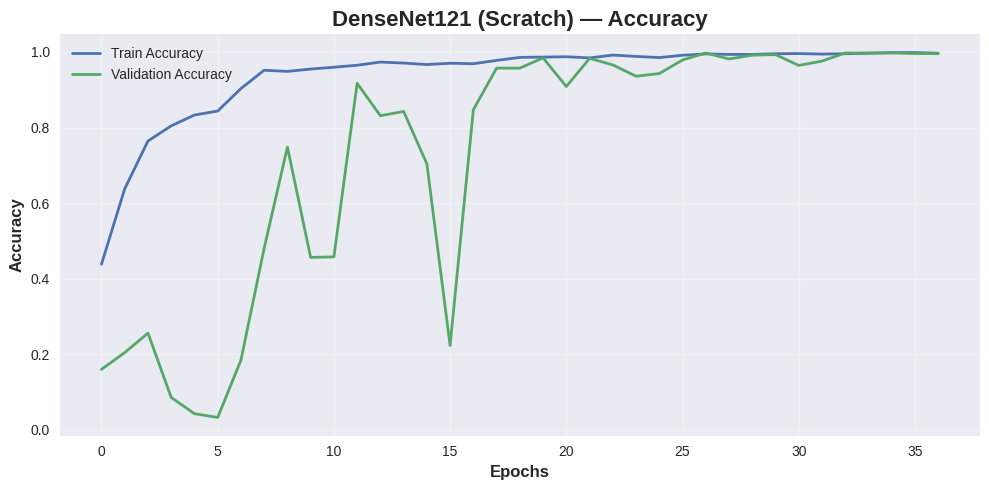

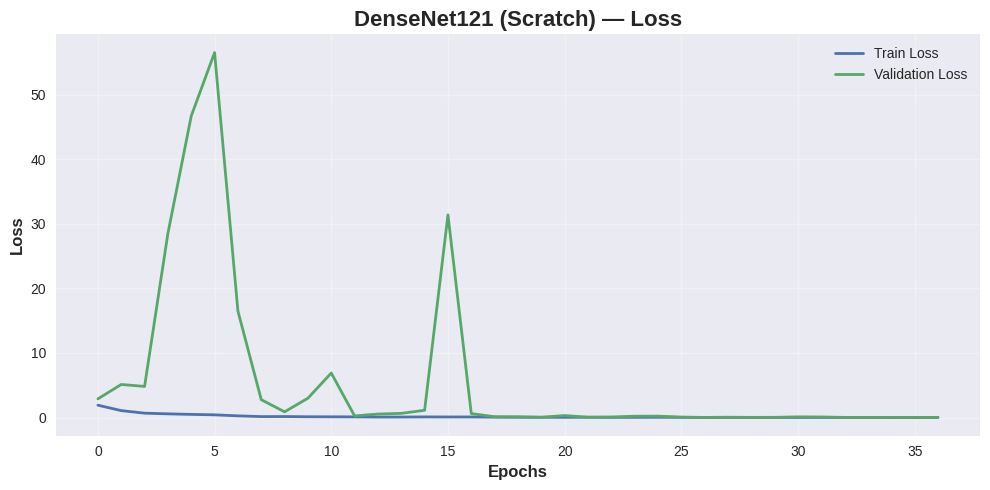

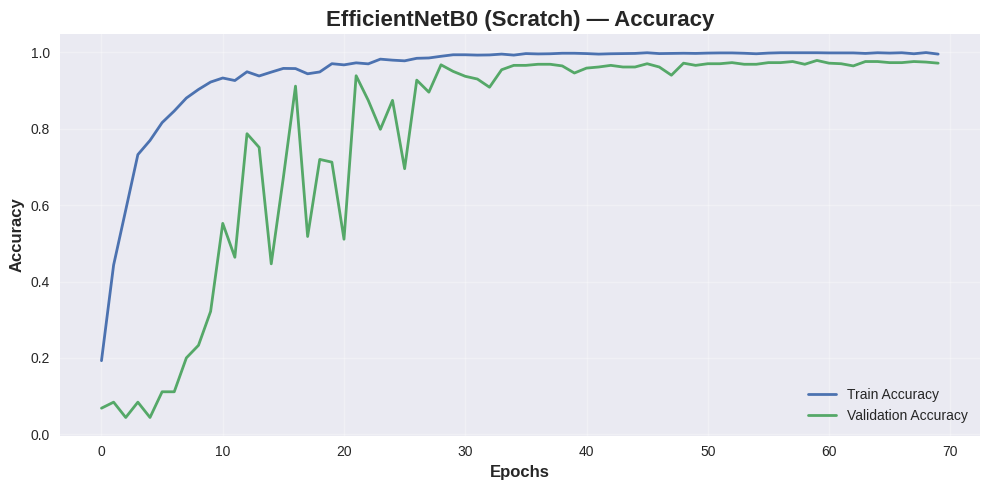

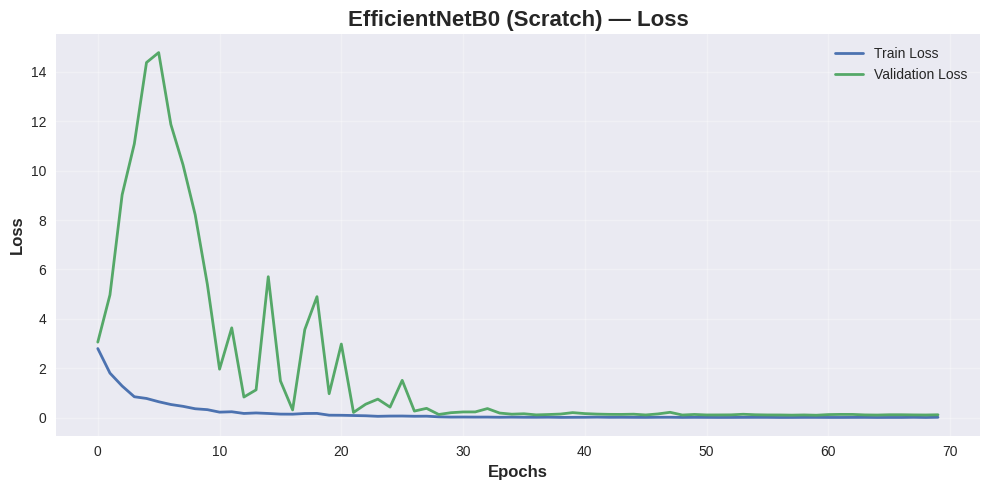

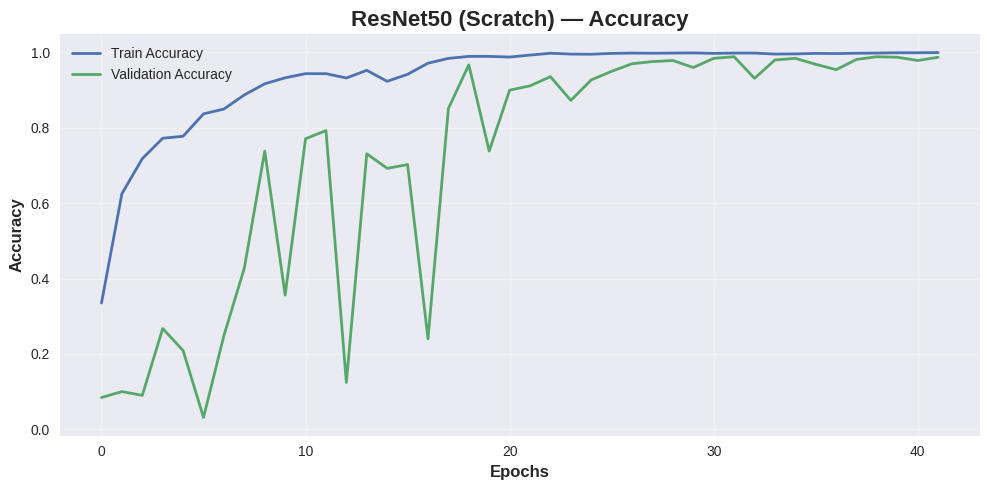

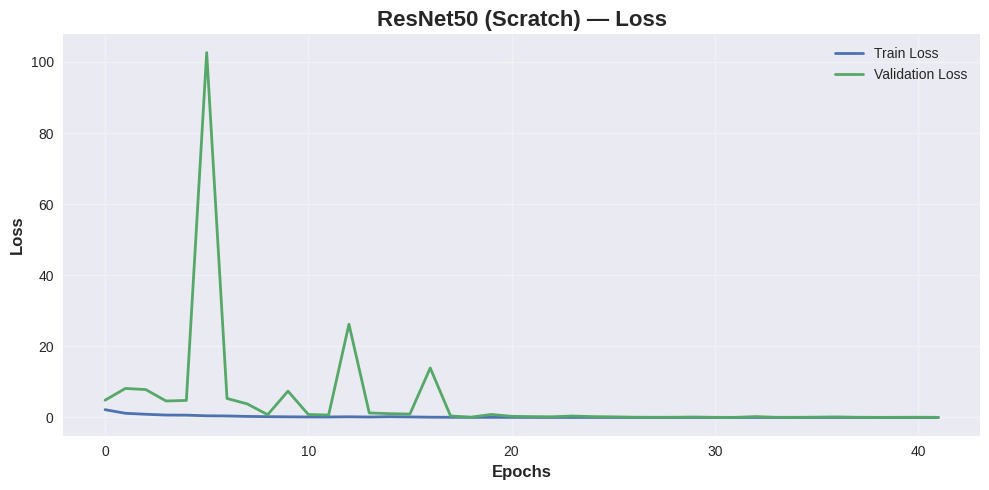


TRAINING SUMMARY STATISTICS
________________________________________________________________________________
Model                               Train Acc    Val Acc      Epochs    
________________________________________________________________________________
DenseNet121 (Pretrained)            0.9987       0.9986       33        
EfficientNetB0 (Pretrained)         0.9996       1.0000       58        
ResNet50 (Pretrained)               1.0000       0.9886       47        
DenseNet121 (Scratch)               0.9965       0.9957       37        
EfficientNetB0 (Scratch)            0.9952       0.9714       70        
ResNet50 (Scratch)                  0.9996       0.9871       42        
________________________________________________________________________________


In [17]:
# Cell 12.1: Training History Visualization 
import matplotlib.pyplot as plt

print("SEPARATE TRAINING HISTORY VISUALIZATION")
print("_" * 80)

plt.style.use("seaborn-v0_8")

if results and any("history" in data for data in results.values()):
    
    for model_key, model_data in results.items():

        history = model_data.get("history", {})
        if not history:
            continue

        # Clean readable model name
        pretty_name = model_key.replace("_pretrained_True", " (Pretrained)").replace("_pretrained_False", " (Scratch)")

        epochs = range(1, len(history.get("accuracy", [])) + 1)

        # =============================
        #   SEPARATE PLOT: ACCURACY
        # =============================
        plt.figure(figsize=(10, 5))
        plt.plot(history.get("accuracy", []), label="Train Accuracy", linewidth=2)
        plt.plot(history.get("val_accuracy", []), label="Validation Accuracy", linewidth=2)

        plt.title(f"{pretty_name} — Accuracy", fontsize=16, fontweight="bold")
        plt.xlabel("Epochs", fontsize=12, fontweight="bold")
        plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()


        # =============================
        #   SEPARATE PLOT: LOSS
        # =============================
        plt.figure(figsize=(10, 5))
        plt.plot(history.get("loss", []), label="Train Loss", linewidth=2)
        plt.plot(history.get("val_loss", []), label="Validation Loss", linewidth=2)

        plt.title(f"{pretty_name} — Loss", fontsize=16, fontweight="bold")
        plt.xlabel("Epochs", fontsize=12, fontweight="bold")
        plt.ylabel("Loss", fontsize=12, fontweight="bold")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()


    # =================================
    #       SUMMARY TABLE
    # =================================
    print("\nTRAINING SUMMARY STATISTICS")
    print("_" * 80)
    print(f"{'Model':<35} {'Train Acc':<12} {'Val Acc':<12} {'Epochs':<10}")
    print("_" * 80)

    for model_key, model_data in results.items():

        history = model_data.get("history", {})
        if history and "accuracy" in history and "val_accuracy" in history:

            pretty_name = model_key.replace("_pretrained_True"," (Pretrained)").replace("_pretrained_False"," (Scratch)")

            train_acc = history["accuracy"][-1]
            val_acc = history["val_accuracy"][-1]
            epochs = len(history["accuracy"])

            print(f"{pretty_name:<35} {train_acc:<12.4f} {val_acc:<12.4f} {epochs:<10}")

    print("_" * 80)

else:
    print("No training history available.")


# Cell 12.2: Enhanced Performance Comparison 

MODEL PERFORMANCE METRICS COMPARISON


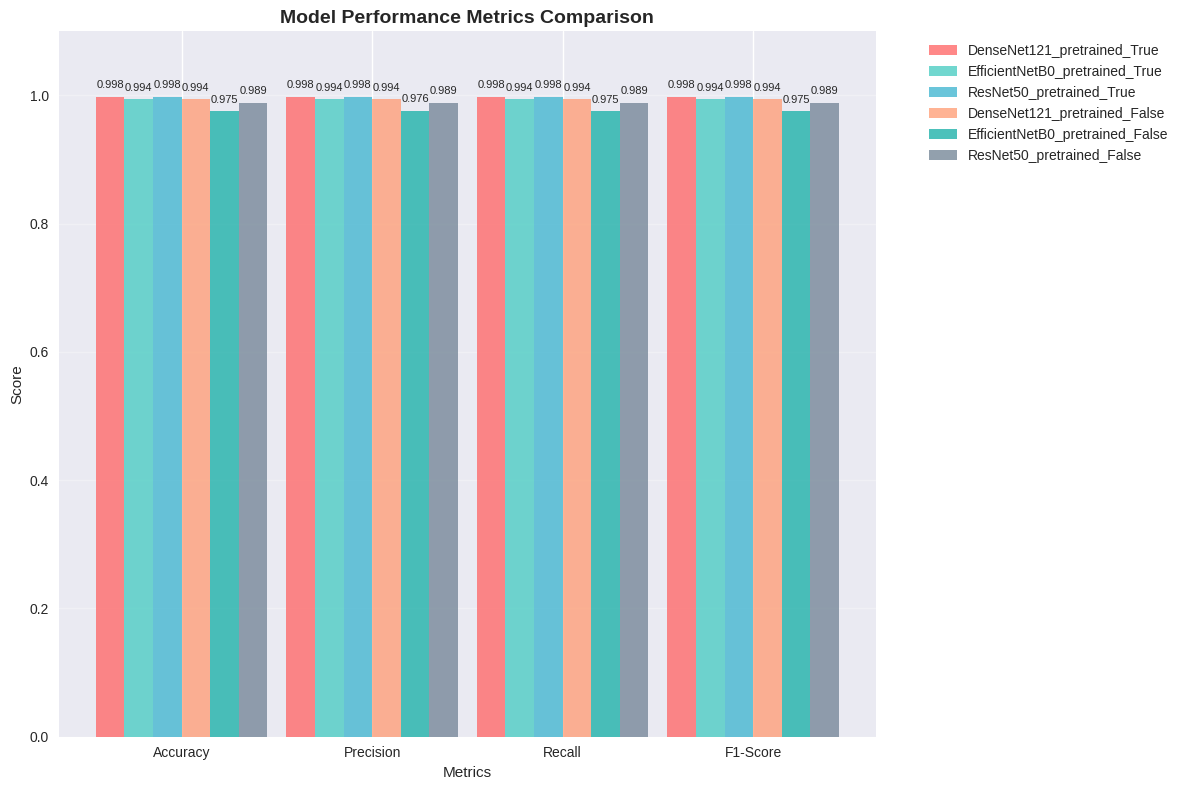

In [18]:

print("MODEL PERFORMANCE METRICS COMPARISON")
plt.figure(figsize=(12, 8))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Prepare data
model_names = []
metric_values = []
pretrained_status = []

for model_key in evaluation_results.keys():
    model_data = evaluation_results[model_key]
    model_metrics = []
    
    for metric in metrics:
        model_metrics.append(model_data[metric])
    
    metric_values.append(model_metrics)
    model_names.append(model_key)
    pretrained_status.append('Pretrained' if 'pretrained_True' in model_key else 'No Pretrain')

# Create grouped bar chart
x = np.arange(len(metric_names))
width = 0.15
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']

for i, (model_metrics, model_name) in enumerate(zip(metric_values, model_names)):
    offset = (i - len(model_names)/2) * width + width/2
    color = colors[i % len(colors)]
    
    bars = plt.bar(x + offset, model_metrics, width, label=model_name, 
                   color=color, alpha=0.8)
    
    # Add value labels on bars
    for bar, value in zip(bars, model_metrics):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.title('Model Performance Metrics Comparison', fontweight='bold', fontsize=14)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks(x, metric_names)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Cell 12.3: Fixed Training and Testing Time Comparison

TRAINING AND TESTING TIME COMPARISON



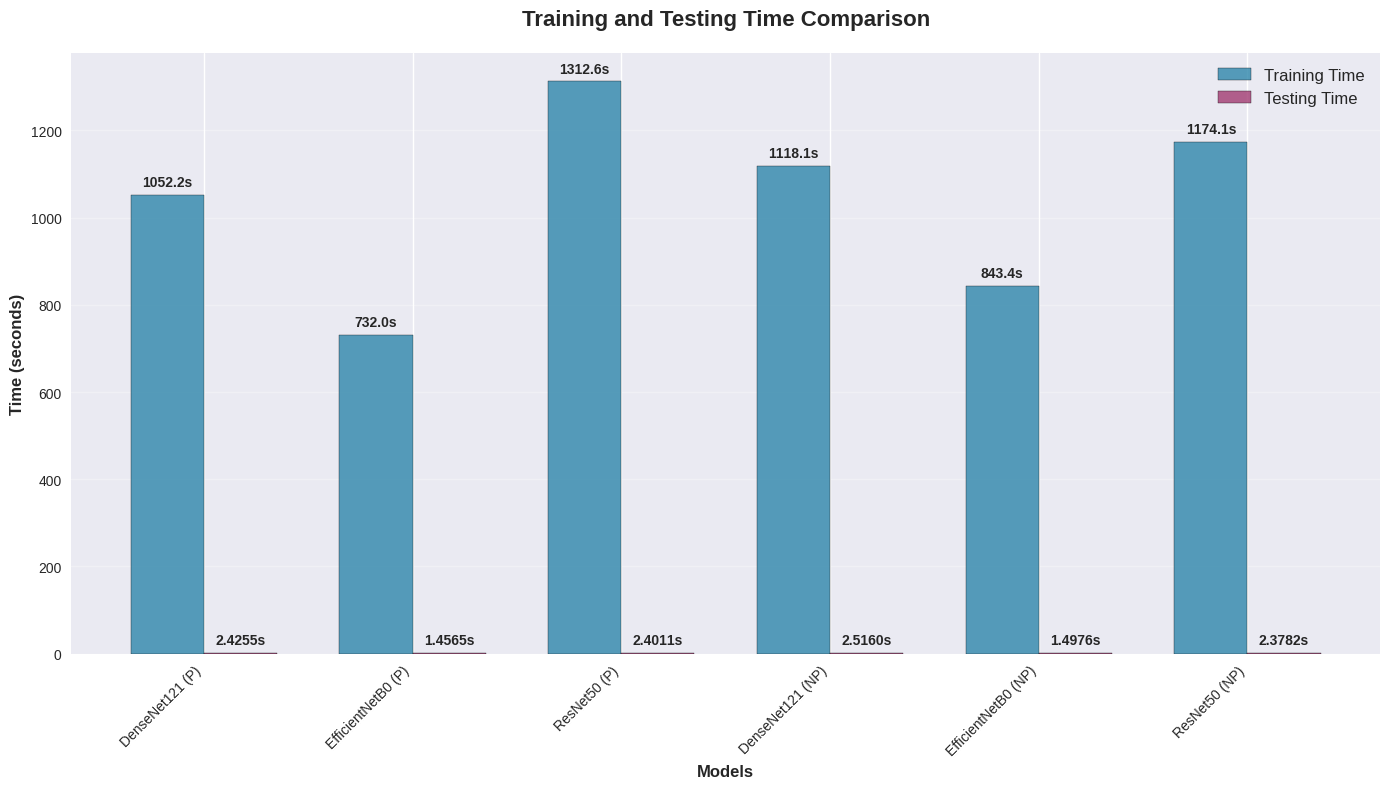


DETAILED TIME ANALYSIS:

Model                          Training Time (s)  Testing Time (s)   Ratio (Train/Test)  
DenseNet121 (Pretrained)       1052.19            2.4255             433.8               
EfficientNetB0 (Pretrained)    731.95             1.4565             502.6               
ResNet50 (Pretrained)          1312.62            2.4011             546.7               
DenseNet121 (Scratch)          1118.15            2.5160             444.4               
EfficientNetB0 (Scratch)       843.41             1.4976             563.2               
ResNet50 (Scratch)             1174.12            2.3782             493.7               

TIME STATISTICS:

Average Training Time: 1038.74 ± 196.68 seconds
Average Testing Time: 2.1125 ± 0.4515 seconds
Total Training Time (all models): 6232.44 seconds
Total Testing Time (all models): 12.6749 seconds

SPEED ANALYSIS:
Fastest Training: EfficientNetB0 (P) (731.95s)
Slowest Training: ResNet50 (P) (1312.62s)
Fastest Testing: Efficient

In [19]:

print("TRAINING AND TESTING TIME COMPARISON\n")


# Check if we have valid data
if not evaluation_results:
    print("No evaluation results available for time comparison.")
else:
    plt.figure(figsize=(14, 8))

    # Safe data extraction
    training_times = []
    testing_times = []
    model_display_names = []
    
    for model_key in evaluation_results.keys():
        # Safe training time access
        train_time = results[model_key].get('training_time', 0)
        test_time = evaluation_results[model_key].get('testing_time', 0)
        
        training_times.append(train_time)
        testing_times.append(test_time)
        
        # Create display name
        display_name = model_key.replace('_pretrained_True', ' (P)').replace('_pretrained_False', ' (NP)')
        model_display_names.append(display_name)

    x = np.arange(len(model_display_names))
    width = 0.35

    # Create bars
    bars1 = plt.bar(x - width/2, training_times, width, label='Training Time', 
                   color='#2E86AB', alpha=0.8, edgecolor='black')
    bars2 = plt.bar(x + width/2, testing_times, width, label='Testing Time', 
                   color='#A23B72', alpha=0.8, edgecolor='black')

    plt.title('Training and Testing Time Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.ylabel('Time (seconds)', fontsize=12, fontweight='bold')
    plt.xticks(x, model_display_names, rotation=45, ha='right')
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Add value labels
    max_time = max(max(training_times), max(testing_times)) if training_times and testing_times else 1
    for i, (train_time, test_time) in enumerate(zip(training_times, testing_times)):
        plt.text(i - width/2, train_time + max_time * 0.01, f'{train_time:.1f}s', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
        plt.text(i + width/2, test_time + max_time * 0.01, f'{test_time:.4f}s', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print detailed time analysis
    print(f"\nDETAILED TIME ANALYSIS:\n")

    print(f"{'Model':<30} {'Training Time (s)':<18} {'Testing Time (s)':<18} {'Ratio (Train/Test)':<20}")
  

    for i, model_key in enumerate(evaluation_results.keys()):
        train_time = training_times[i]
        test_time = testing_times[i]
        ratio = train_time / test_time if test_time > 0 else float('inf')
        display_name = model_key.replace('_pretrained_True', ' (Pretrained)').replace('_pretrained_False', ' (Scratch)')
        print(f"{display_name:<30} {train_time:<18.2f} {test_time:<18.4f} {ratio:<20.1f}")


    # Time statistics
    print(f"\nTIME STATISTICS:\n")
    print(f"Average Training Time: {np.mean(training_times):.2f} ± {np.std(training_times):.2f} seconds")
    print(f"Average Testing Time: {np.mean(testing_times):.4f} ± {np.std(testing_times):.4f} seconds")
    print(f"Total Training Time (all models): {sum(training_times):.2f} seconds")
    print(f"Total Testing Time (all models): {sum(testing_times):.4f} seconds")
    
    # Speed analysis
    fastest_train_idx = np.argmin(training_times)
    slowest_train_idx = np.argmax(training_times)
    fastest_test_idx = np.argmin(testing_times)
    slowest_test_idx = np.argmax(testing_times)
    
    print(f"\nSPEED ANALYSIS:")
    print(f"Fastest Training: {model_display_names[fastest_train_idx]} ({training_times[fastest_train_idx]:.2f}s)")
    print(f"Slowest Training: {model_display_names[slowest_train_idx]} ({training_times[slowest_train_idx]:.2f}s)")
    print(f"Fastest Testing: {model_display_names[fastest_test_idx]} ({testing_times[fastest_test_idx]:.4f}s)")
    print(f"Slowest Testing: {model_display_names[slowest_test_idx]} ({testing_times[slowest_test_idx]:.4f}s)")
    
    # Efficiency analysis
    print(f"\nEFFICIENCY ANALYSIS:")
    efficiency_ratios = [train/test if test > 0 else 0 for train, test in zip(training_times, testing_times)]
    most_efficient_idx = np.argmax(efficiency_ratios)
    least_efficient_idx = np.argmin(efficiency_ratios)
    
    print(f"Most Efficient (Highest Train/Test Ratio): {model_display_names[most_efficient_idx]} ({efficiency_ratios[most_efficient_idx]:.1f}x)")
    print(f"Least Efficient (Lowest Train/Test Ratio): {model_display_names[least_efficient_idx]} ({efficiency_ratios[least_efficient_idx]:.1f}x)")
    print(f"Average Efficiency Ratio: {np.mean(efficiency_ratios):.1f}x")
    

# Cell 12.4: Class-wise Accuracy Comparison 

CLASS-WISE ACCURACY COMPARISON



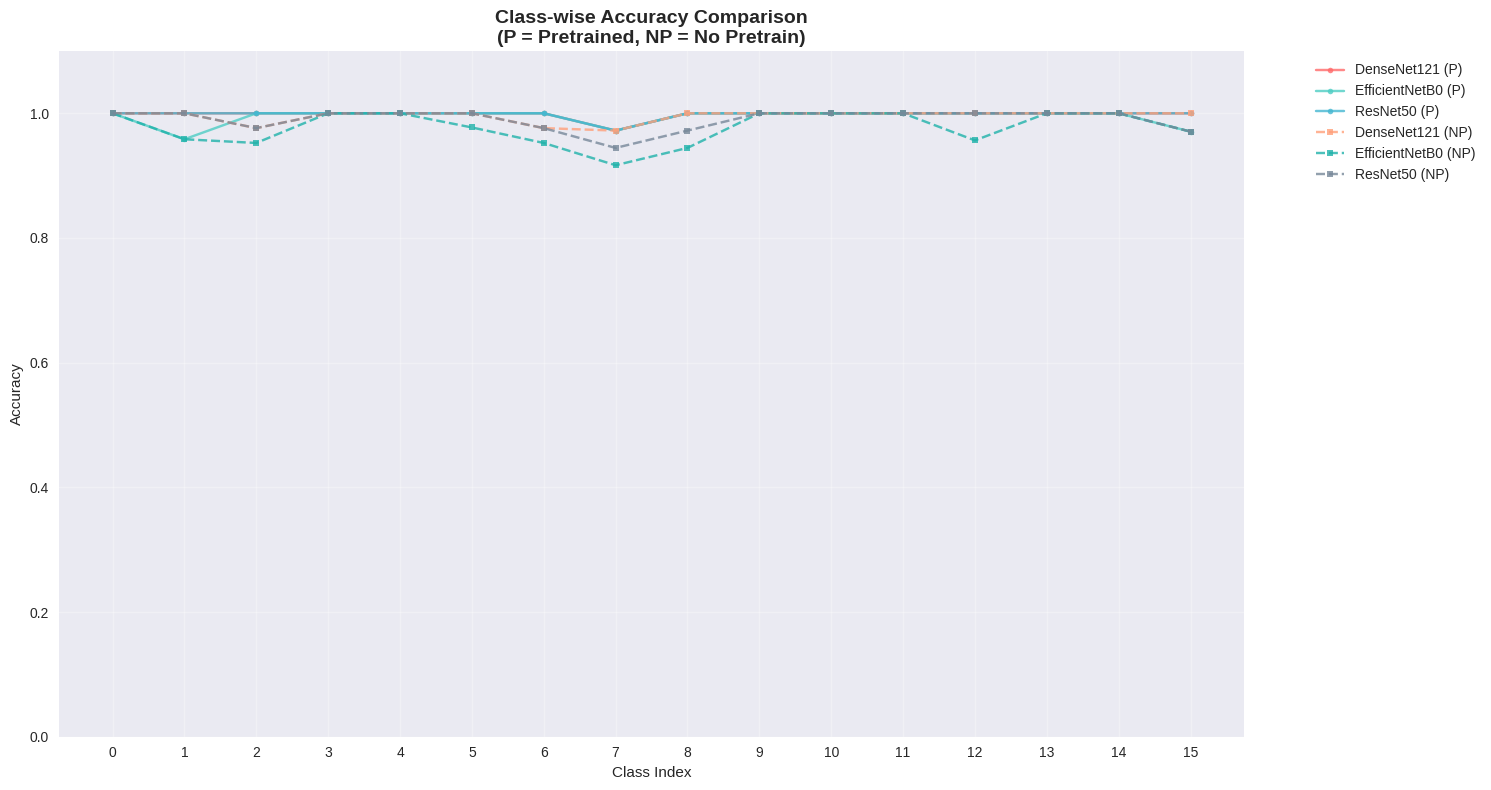

In [20]:

print("CLASS-WISE ACCURACY COMPARISON\n")

plt.figure(figsize=(15, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']

for i, (model_key, eval_data) in enumerate(evaluation_results.items()):
    color = colors[i % len(colors)]
    
    if 'pretrained_True' in model_key:
        linestyle = '-'
        marker = 'o'
        label_suffix = ' (P)'
    else:
        linestyle = '--'
        marker = 's'
        label_suffix = ' (NP)'
    
    model_name = model_key.replace('_pretrained_True', '').replace('_pretrained_False', '')
    
    plt.plot(range(len(class_names)), eval_data['class_accuracy'], 
             marker=marker, linestyle=linestyle, label=f'{model_name}{label_suffix}', 
             color=color, alpha=0.8, markersize=4)

plt.title('Class-wise Accuracy Comparison\n(P = Pretrained, NP = No Pretrain)', 
          fontweight='bold', fontsize=14)
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.xticks(range(len(class_names)), range(len(class_names)))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.ylim(0, 1.1)

# Add class names on secondary x-axis if needed
plt.tight_layout()
plt.show()

# Cell 12.5: Best Model Confusion Matrix 

BEST MODEL CONFUSION MATRIX



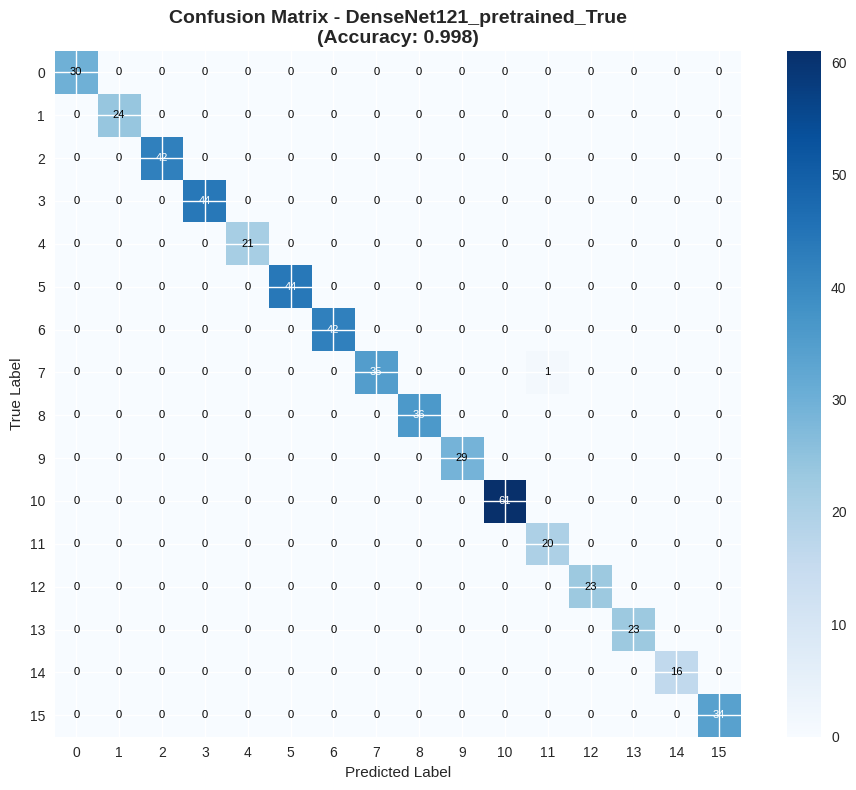

Best performing model: DenseNet121_pretrained_True with accuracy: 0.9981


In [21]:

print("BEST MODEL CONFUSION MATRIX\n")


# Find best model based on accuracy
best_model_key = max(evaluation_results.keys(), 
                    key=lambda x: evaluation_results[x]['accuracy'])
best_eval = evaluation_results[best_model_key]

cm = confusion_matrix(best_eval['y_true'], best_eval['y_pred'])

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, cmap='Blues', interpolation='nearest')

plt.title(f'Confusion Matrix - {best_model_key}\n(Accuracy: {best_eval["accuracy"]:.3f})', 
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(class_names)))
plt.yticks(range(len(class_names)))

# Add text annotations
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"Best performing model: {best_model_key} with accuracy: {best_eval['accuracy']:.4f}")

# Cell 13: Statistical comparison with paired t-test

In [22]:

from scipy import stats

def perform_statistical_comparison(evaluation_results):
    """Perform paired t-test for statistical comparison"""
    
    print("STATISTICAL COMPARISON (Paired t-test)")
    print("_" * 50)
    
    model_names = list(evaluation_results.keys())
    
    # Compare each pair of models
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]
            
            # Get predictions
            pred1 = evaluation_results[model1]['y_pred']
            pred2 = evaluation_results[model2]['y_pred']
            true_labels = evaluation_results[model1]['y_true']
            
            # Calculate per-sample accuracy
            acc1 = (pred1 == true_labels).astype(int)
            acc2 = (pred2 == true_labels).astype(int)
            
            # Perform paired t-test
            t_stat, p_value = stats.ttest_rel(acc1, acc2)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  T-statistic: {t_stat:.4f}")
            print(f"  P-value: {p_value:.4f}")
            
            if p_value < 0.05:
                if np.mean(acc1) > np.mean(acc2):
                    print(f"  {model1} performs SIGNIFICANTLY better than {model2}")
                else:
                    print(f"  {model2} performs SIGNIFICANTLY better than {model1}")
            else:
                print(f"  No significant difference between {model1} and {model2}")

perform_statistical_comparison(evaluation_results)

STATISTICAL COMPARISON (Paired t-test)
__________________________________________________

DenseNet121_pretrained_True vs EfficientNetB0_pretrained_True:
  T-statistic: 1.4156
  P-value: 0.1575
  No significant difference between DenseNet121_pretrained_True and EfficientNetB0_pretrained_True

DenseNet121_pretrained_True vs ResNet50_pretrained_True:
  T-statistic: nan
  P-value: nan
  No significant difference between DenseNet121_pretrained_True and ResNet50_pretrained_True

DenseNet121_pretrained_True vs DenseNet121_pretrained_False:
  T-statistic: 1.4156
  P-value: 0.1575
  No significant difference between DenseNet121_pretrained_True and DenseNet121_pretrained_False

DenseNet121_pretrained_True vs EfficientNetB0_pretrained_False:
  T-statistic: 3.5010
  P-value: 0.0005
  DenseNet121_pretrained_True performs SIGNIFICANTLY better than EfficientNetB0_pretrained_False

DenseNet121_pretrained_True vs ResNet50_pretrained_False:
  T-statistic: 2.2447
  P-value: 0.0252
  DenseNet121_pretrain

# Cell 14: Evaluation results

CREATING COMPREHENSIVE RESULTS TABLE

Processing model: DenseNet121_pretrained_True
Processing model: EfficientNetB0_pretrained_True
Processing model: ResNet50_pretrained_True
Processing model: DenseNet121_pretrained_False
Processing model: EfficientNetB0_pretrained_False
Processing model: ResNet50_pretrained_False

FINAL MODEL PERFORMANCE COMPARISON



,Model,Pretrained,Accuracy,Precision,Recall,F1-Score,AUC (Micro),Training Time (s),Testing Time (s),Best Val Accuracy
0,DenseNet121,Yes,0.9981,0.9982,0.9981,0.9981,1.0000,1052.19,2.4255,1.0000
2,ResNet50,Yes,0.9981,0.9982,0.9981,0.9981,0.9999,1312.62,2.4011,0.9957
1,EfficientNetB0,Yes,0.9943,0.9944,0.9943,0.9943,1.0000,731.95,1.4565,1.0000
3,DenseNet121,No,0.9943,0.9944,0.9943,0.9943,0.9999,1118.15,2.5160,0.9971
5,ResNet50,No,0.9886,0.9888,0.9886,0.9886,1.0000,1174.12,2.3782,0.9886
4,EfficientNetB0,No,0.9752,0.9760,0.9752,0.9753,0.9998,843.41,1.4976,0.9785



PERFORMANCE SUMMARY STATISTICS

Average Accuracy: 0.9914 ± 0.0087
Average F1-Score: 0.9914 ± 0.0086
Average AUC: 0.9999 ± 0.0001
Average Training Time: 1038.74s ± 215.45s
Average Testing Time: 2.1125s ± 0.4946s

TOP PERFORMERS

Best Accuracy: DenseNet121 (0.9981)
Best F1-Score: DenseNet121 (0.9981)
Fastest Training: EfficientNetB0 (731.95s)

PRETRAINED VS FROM SCRATCH COMPARISON

Pretrained Models (n=3):
  Average Accuracy: 0.9968
  Average Training Time: 1032.25s
Scratch Models (n=3):
  Average Accuracy: 0.9860
  Average Training Time: 1045.23s
Accuracy Difference: 0.0108 (Pretrained wins)

Results table created successfully with 6 models!

ADDITIONAL PERFORMANCE VISUALIZATIONS



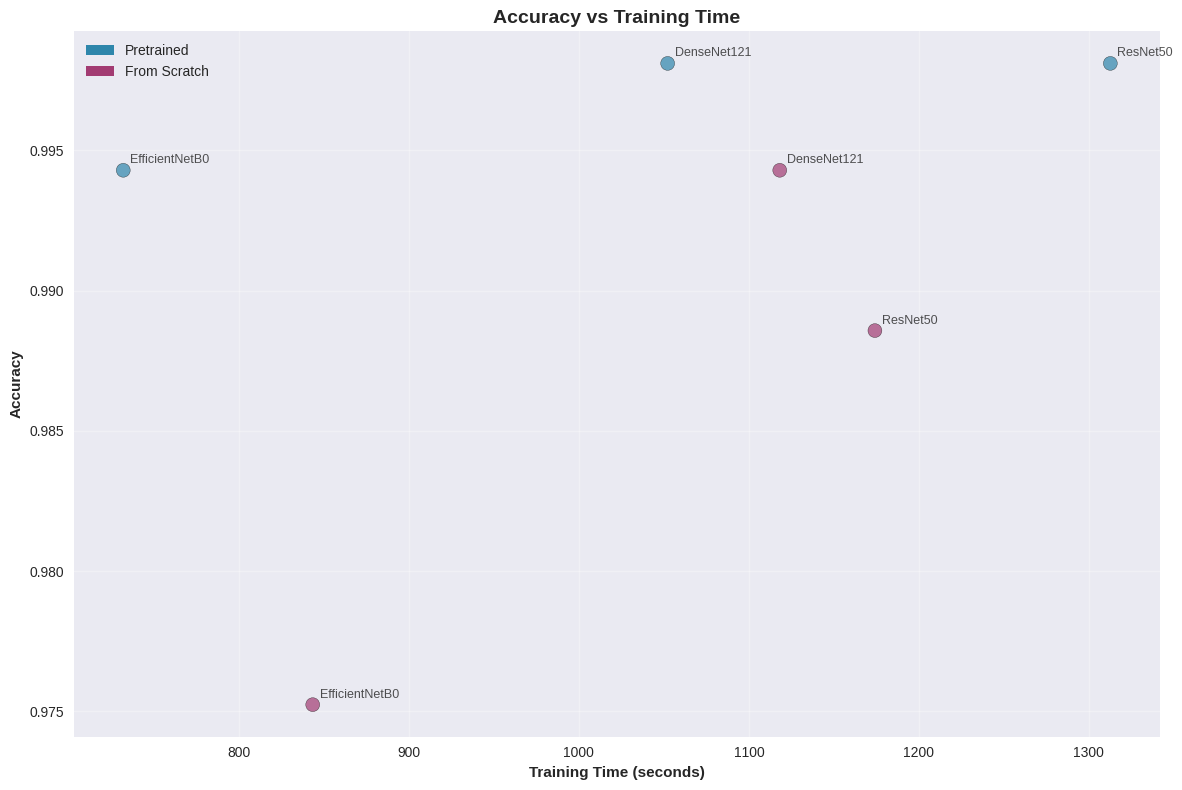


MODEL RANKINGS BY ACCURACY

 1. DenseNet121     0.9981 (Pretrained: Yes)
 2. ResNet50        0.9981 (Pretrained: Yes)
 3. EfficientNetB0  0.9943 (Pretrained: Yes)
 4. DenseNet121     0.9943 (Pretrained: No)
 5. ResNet50        0.9886 (Pretrained: No)
 6. EfficientNetB0  0.9752 (Pretrained: No)

EXPERIMENTAL PROTOCOL SUMMARY
All models were trained using an identical experimental protocol, 
including the same dataset splits, preprocessing pipeline, data augmentation, 
optimizer, learning rate schedule, class-weighted loss, batch size, and early 
stopping criteria. Performance differences therefore reflect architectural 
design rather than training configuration bias.


In [23]:
def create_results_table(evaluation_results, results):
    
    if len(evaluation_results) == 0:
        print("evaluation_results is EMPTY — nothing to summarize.")
        return None

    if len(results) == 0:
        print("results dictionary is EMPTY — training data missing.")
        return None
    
    print("CREATING COMPREHENSIVE RESULTS TABLE\n")
    
    table_data = []
    
    for model_key in evaluation_results.keys():
        print(f"Processing model: {model_key}")

        eval_data = evaluation_results[model_key]
        training_data = results[model_key]

        # Extract best validation accuracy - FIX: Access as dictionary, not .history
        history = training_data["history"]
        if "val_accuracy" in history:
            best_val_acc = max(history["val_accuracy"])
        else:
            best_val_acc = 0.0

        # Get pretrained status
        pretrained_status = "Yes" if training_data.get('pretrained', True) else "No"

        # Create simplified model name for display
        model_display_name = model_key.replace('_pretrained_True', '').replace('_pretrained_False', '')
        
        row = {
            "Model": model_display_name,
            "Pretrained": pretrained_status,
            "Accuracy": eval_data['accuracy'],
            "Precision": eval_data['precision'],
            "Recall": eval_data['recall'],
            "F1-Score": eval_data['f1_score'],
            "AUC (Micro)": eval_data['auc_scores']['micro'],
            "Training Time (s)": training_data.get('training_time', 0),
            "Testing Time (s)": eval_data['testing_time'],
            "Best Val Accuracy": best_val_acc
        }

        table_data.append(row)

    df_results = pd.DataFrame(table_data)
    
    # Sort by Accuracy (descending)
    df_results = df_results.sort_values('Accuracy', ascending=False)
    
    # Create styled table
    styled_df = df_results.style \
        .format({
            'Accuracy': '{:.4f}',
            'Precision': '{:.4f}',
            'Recall': '{:.4f}',
            'F1-Score': '{:.4f}',
            'AUC (Micro)': '{:.4f}',
            'Training Time (s)': '{:.2f}',
            'Testing Time (s)': '{:.4f}',
            'Best Val Accuracy': '{:.4f}'
        }) \
        .background_gradient(subset=['Accuracy', 'F1-Score', 'AUC (Micro)'], cmap='YlGnBu') \
        .background_gradient(subset=['Training Time (s)', 'Testing Time (s)'], cmap='RdYlGn_r') \
        .set_properties(**{
            'border': '1px solid black',
            'text-align': 'center'
        }) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2E86AB'), 
                                       ('color', 'white'),
                                       ('font-weight', 'bold'),
                                       ('text-align', 'center'),
                                       ('border', '1px solid black')]},
            {'selector': 'td', 'props': [('border', '1px solid black'),
                                       ('text-align', 'center')]},
            {'selector': '', 'props': [('border-collapse', 'collapse')]}
        ])
    
    # Display the styled table
    print("\nFINAL MODEL PERFORMANCE COMPARISON\n")
    display(styled_df)
    
    # Print summary statistics
    print(f"\nPERFORMANCE SUMMARY STATISTICS\n")
    print(f"Average Accuracy: {df_results['Accuracy'].mean():.4f} ± {df_results['Accuracy'].std():.4f}")
    print(f"Average F1-Score: {df_results['F1-Score'].mean():.4f} ± {df_results['F1-Score'].std():.4f}")
    print(f"Average AUC: {df_results['AUC (Micro)'].mean():.4f} ± {df_results['AUC (Micro)'].std():.4f}")
    print(f"Average Training Time: {df_results['Training Time (s)'].mean():.2f}s ± {df_results['Training Time (s)'].std():.2f}s")
    print(f"Average Testing Time: {df_results['Testing Time (s)'].mean():.4f}s ± {df_results['Testing Time (s)'].std():.4f}s")
    
    # Find best models
    best_accuracy_model = df_results.loc[df_results['Accuracy'].idxmax()]
    best_f1_model = df_results.loc[df_results['F1-Score'].idxmax()]
    fastest_model = df_results.loc[df_results['Training Time (s)'].idxmin()]
    
    print(f"\nTOP PERFORMERS\n")
    print(f"Best Accuracy: {best_accuracy_model['Model']} ({best_accuracy_model['Accuracy']:.4f})")
    print(f"Best F1-Score: {best_f1_model['Model']} ({best_f1_model['F1-Score']:.4f})")
    print(f"Fastest Training: {fastest_model['Model']} ({fastest_model['Training Time (s)']:.2f}s)")
    
    # Compare pretrained vs scratch
    pretrained_stats = df_results[df_results['Pretrained'] == 'Yes']
    scratch_stats = df_results[df_results['Pretrained'] == 'No']
    
    if len(pretrained_stats) > 0 and len(scratch_stats) > 0:
        print(f"\nPRETRAINED VS FROM SCRATCH COMPARISON\n")
        print(f"Pretrained Models (n={len(pretrained_stats)}):")
        print(f"  Average Accuracy: {pretrained_stats['Accuracy'].mean():.4f}")
        print(f"  Average Training Time: {pretrained_stats['Training Time (s)'].mean():.2f}s")
        print(f"Scratch Models (n={len(scratch_stats)}):")
        print(f"  Average Accuracy: {scratch_stats['Accuracy'].mean():.4f}")
        print(f"  Average Training Time: {scratch_stats['Training Time (s)'].mean():.2f}s")
        
        accuracy_diff = pretrained_stats['Accuracy'].mean() - scratch_stats['Accuracy'].mean()
        print(f"Accuracy Difference: {accuracy_diff:.4f} (Pretrained {'wins' if accuracy_diff > 0 else 'loses'})")
    
    return df_results

# Create the final results table
final_results_table = create_results_table(evaluation_results, results)

if final_results_table is not None:
    print(f"\nResults table created successfully with {len(final_results_table)} models!")
    
    # Additional visualizations
    print(f"\nADDITIONAL PERFORMANCE VISUALIZATIONS\n")
    
    # Create performance scatter plot
    plt.figure(figsize=(12, 8))
    
    colors = ['#2E86AB' if pt == 'Yes' else '#A23B72' for pt in final_results_table['Pretrained']]
    
    plt.scatter(final_results_table['Training Time (s)'], 
                final_results_table['Accuracy'], 
                c=colors, s=100, alpha=0.7, edgecolors='black')
    
    # Add model labels
    for i, row in final_results_table.iterrows():
        plt.annotate(row['Model'], 
                    (row['Training Time (s)'], row['Accuracy']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.8)
    
    plt.xlabel('Training Time (seconds)', fontweight='bold')
    plt.ylabel('Accuracy', fontweight='bold')
    plt.title('Accuracy vs Training Time', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2E86AB', label='Pretrained'),
                      Patch(facecolor='#A23B72', label='From Scratch')]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Performance ranking
    print(f"\nMODEL RANKINGS BY ACCURACY\n")
    ranked_models = final_results_table.sort_values('Accuracy', ascending=False)
    for i, (idx, row) in enumerate(ranked_models.iterrows(), 1):
        print(f"{i:2d}. {row['Model']:<15} {row['Accuracy']:.4f} (Pretrained: {row['Pretrained']})")
        # === ADD AT THE END OF CELL 14 ===
print("\n" + "="*80)
print("EXPERIMENTAL PROTOCOL SUMMARY")
print("="*80)
print("""All models were trained using an identical experimental protocol, 
including the same dataset splits, preprocessing pipeline, data augmentation, 
optimizer, learning rate schedule, class-weighted loss, batch size, and early 
stopping criteria. Performance differences therefore reflect architectural 
design rather than training configuration bias.""")
print("="*80)

# Cell 15: Save models and results

In [24]:

print("Saving models and results...")

# Save all models
for model_key, model_data in results.items():
    model = model_data['model']
    safe_filename = model_key.replace(' ', '_').replace('/', '_')
    model.save(f'{safe_filename}_final_model.h5')
    print(f"Saved: {safe_filename}_final_model.h5")

# Save results to CSV
if final_results_table is not None:
    final_results_table.to_csv('task2_model_comparison_results.csv', index=False)
    print("Results table saved to CSV")

# Save evaluation results
import pickle
with open('task2_evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)
print("Evaluation results pickled")

print("All models and results saved successfully!")

Saving models and results...


Saved: DenseNet121_pretrained_True_final_model.h5


Saved: EfficientNetB0_pretrained_True_final_model.h5


Saved: ResNet50_pretrained_True_final_model.h5


Saved: DenseNet121_pretrained_False_final_model.h5


Saved: EfficientNetB0_pretrained_False_final_model.h5
Saved: ResNet50_pretrained_False_final_model.h5
Results table saved to CSV
Evaluation results pickled
All models and results saved successfully!
